# Lilian Sudi - Case Study
## Demand & Least-Cost Electrification Modelling for Benin


This notebook answers three questions:
1. **How much electricity does each settlement need?** (Demand estimation)
2. **What is the cheapest way to provide it?** (Least-cost technology analysis)
3. **Which settlements should be prioritised for investment?** (Prioritisation)

### Files you needed in the same folder as this notebook
- `Benin_settlement_properties.geojson`: the settlements data
- `Benin_existing_transmission_lines_2017.geojson`: the grid data
- `gadm41_BEN_1.json`: the administrative boundaries data (downloaded from GADM)



## Install and Import Libraries

- **geopandas** for working with maps and geographic data
- **pandas** for working with tables of data (like Excel but in Python)
- **numpy** for mathematical calculations
- **matplotlib** for drawing charts and graphs
- **shapely** for calculating areas, distances, overlaps
- **fiona** for opening GeoJSON and Shapefile formats
- **pyproj** for accurate distance calculations
- **folium** for browser-based zoomable maps

In [39]:
# !pip install geopandas matplotlib numpy pandas shapely fiona pyproj folium

print("If you see no errors above, libraries are already installed.")
print("If you see errors, uncomment the !pip install line and run again.")

If you see no errors above, libraries are already installed.
If you see errors, uncomment the !pip install line and run again.


In [40]:
import geopandas as gpd        # For geographic/spatial data (maps, coordinates)
import pandas as pd            # For data tables and analysis
import numpy as np             # For mathematical operations
import matplotlib.pyplot as plt  # For drawing charts
import matplotlib.patches as mpatches  # For chart legends
import matplotlib.gridspec as gridspec  # For complex chart layouts
import json                    # For reading GeoJSON files
import warnings
warnings.filterwarnings('ignore')  # Suppress minor warnings for cleaner output

# Make charts appear inside the notebook (not in a separate window)
%matplotlib inline

# Set a consistent visual style for charts displayed
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'sans-serif'

# Define consistent colours for the three technologies
# These will be used in all charts so colours are consistent throughout
TECH_COLORS = {
    'Grid Extension':    '#1a6b9a',   # Blue
    'Mini-Grid':         '#e8820c',   # Orange
    'Solar Home System': '#2d8a4e'    # Green
}

print(" All libraries loaded successfully")
print(f"   GeoPandas version: {gpd.__version__}")
print(f"   Pandas version: {pd.__version__}")
print(f"   NumPy version: {np.__version__}")

 All libraries loaded successfully
   GeoPandas version: 1.1.3
   Pandas version: 2.2.2
   NumPy version: 2.0.2



## Review Data

1. **Settlements** - 17,205 features, each representing a village or town in Benin
2. **Transmission lines** - the existing MV (medium voltage) electricity grid

In [41]:
from google.colab import drive  # mount Google Drive since files were uploaded there.
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
## Review Settlements Data

settlements = gpd.read_file('/content/drive/My Drive/Lilian_Sudi_VIDA_Benin_Case_Study/Benin_settlement_properties.geojson')
# load the file

# Print basic information about the dataset
print("SETTLEMENTS DATASET")
print(f"Coordinate system (CRS): {settlements.crs}")
# .shape expounds on (rows, columns)
print(f"\nRows (settlements): {settlements.shape[0]:,}")
print(f"Columns (variables): {settlements.shape[1]}")

# .dtypes expounds on what type each column is
# object = text, float64 = decimal number, bool = True/False, geometry = map shape
print("\nColumn types:")
print(settlements.dtypes)

SETTLEMENTS DATASET
Coordinate system (CRS): EPSG:4326

Rows (settlements): 17,205
Columns (variables): 48

Column types:
lat                                                  float64
lon                                                  float64
demand                                               float64
mean_rwi                                             float64
hull_area                                            float64
identifier                                             int32
population                                             int32
buffer_area                                          float64
description                                           object
admin_cgaz_0                                          object
admin_cgaz_1                                          object
admin_cgaz_2                                          object
overlap_area                                         float64
village_name                                          object
bf_total_area           

 5 columns have missing values:



,Missing Count,Missing %,Data Type
description,17205,100.00,object
mean_rwi,1059,6.16,float64
admin_cgaz_0,11,0.06,object
admin_cgaz_1,11,0.06,object
admin_cgaz_2,11,0.06,object


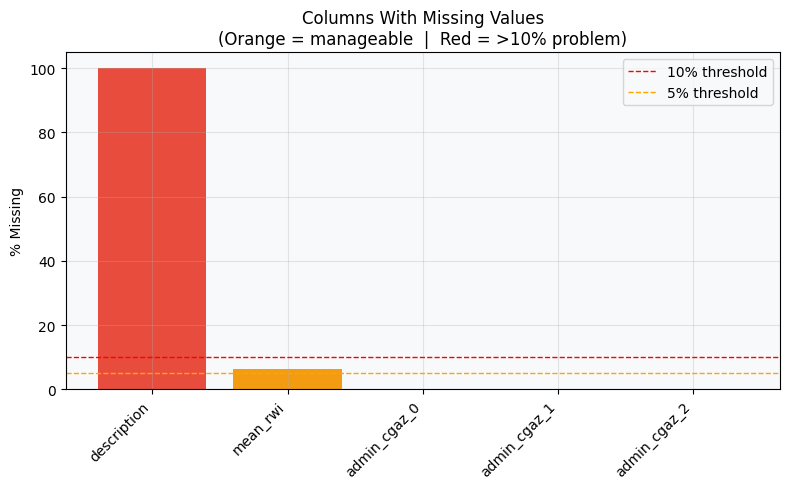

In [43]:
# Analysing missing values

# Calculate missing count and percentage for every column
missing = settlements.isnull().sum()
missing_pct = (missing / len(settlements) * 100).round(2)

# Build summary table for rows where something is actually missing
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Data Type': settlements.dtypes
})
missing_only = missing_summary[missing_summary['Missing Count'] > 0].sort_values(
    'Missing %', ascending=False
)

# Print or confirm clean
if len(missing_only) == 0:
    print(" No missing values found in any column")
else:
    print(f" {len(missing_only)} columns have missing values:\n")
    display(missing_only)  # renders as a table

# Chart if there is something to show
if len(missing_only) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#e74c3c' if v > 10 else '#f39c12' for v in missing_only['Missing %']]
    ax.bar(range(len(missing_only)), missing_only['Missing %'], color=colors)
    ax.set_xticks(range(len(missing_only)))
    ax.set_xticklabels(missing_only.index, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('% Missing')
    ax.set_title('Columns With Missing Values\n(Orange = manageable  |  Red = >10% problem)')
    ax.axhline(10, color='red', linestyle='--', linewidth=1, label='10% threshold')
    ax.axhline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [44]:
# Only drop 'description' if it's truly empty
if settlements['description'].isnull().all():
    settlements = settlements.drop(columns=['description'])
    print("Dropped: Confirmed 100% empty, no information loss")
else:
    print("Kept: Contains some values useful for identification")
    print(settlements['description'].value_counts(dropna=False).head(10))

Dropped: Confirmed 100% empty, no information loss


In [45]:
# Analyse RWI column

data = settlements['mean_rwi'].dropna() # Remove missing values before calculating statistics

# Calculate the three key numbers
mean   = data.mean()    # Average - pulled by extreme values
median = data.median()  # Middle value - not affected by extremes
skew   = data.skew()    # Measures how lopsided the distribution is

print(f"Mean:   {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Skew:   {skew:.4f}")
print()

# If skew is beyond ±0.5, outliers are pulling the mean and median is used
if abs(skew) > 0.5:
    fill_value = median
    print(f"Skew is {skew:.2f} : distribution is skewed, use MEDIAN")
else:
    fill_value = mean
    print(f"Skew is {skew:.2f} : distribution is symmetric, use MEAN")

# Fill the 1,059 missing RWI values with what was chosen above
settlements['mean_rwi'] = settlements['mean_rwi'].fillna(fill_value)

print(f"\n Filled missing RWI values with: {fill_value:.4f}")
print(f"   Remaining missing: {settlements['mean_rwi'].isnull().sum()}")

Mean:   -0.3583
Median: -0.3920
Skew:   0.9031

Skew is 0.90 : distribution is skewed, use MEDIAN

 Filled missing RWI values with: -0.3920
   Remaining missing: 0


In [46]:
# Fill missing admin names with 'Unknown', 11 rows are negligible
for col in ['admin_cgaz_0', 'admin_cgaz_1', 'admin_cgaz_2']:
    settlements[col] = settlements[col].fillna('Unknown')

print("Filled 11 missing admin area names with 'Unknown'")

Filled 11 missing admin area names with 'Unknown'


In [47]:
# Confirm no missing values remain
remaining_missing = settlements.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print(" All missing values handled and dataset is clean")
else:
    print(" Still have missing values:")
    print(remaining_missing)

 All missing values handled and dataset is clean


In [48]:
# Data Overview

# Population drives electricity demand and determines how many households need to be connected
print(f"\n POPULATION")
print(f"   Total population: {settlements['population'].sum():,}")
print(f"   Smallest settlement: {settlements['population'].min():,} people")
print(f"   Largest settlement: {settlements['population'].max():,} people")
print(f"   Median: {settlements['population'].median():.0f} people")
print(f"   Mean:   {settlements['population'].mean():.0f} people")

# Check distribution
median_pop = settlements['population'].median()
mean_pop   = settlements['population'].mean()
gap        = mean_pop - median_pop

print(f"\n   Mean is {gap:,.0f} higher than median")

if gap > median_pop:
    # Mean more than double median. Most settlements are small villages; a few are large cities
    print("   Huge range: mean is double the median")
    print("   Most settlements are small, with a few very large cities")
else:
    # Mean and median close together = roughly symmetric distribution
    print("   Mean and median are close, distribution is relatively symmetric")


# ENERGY DEMAND
# Dataset pre-computes demand in MWh/year using the Multi-Tier Framework
# This as my Year 1 baseline
print("\n ENERGY DEMAND (MWh/year)")
print(f"   Total demand: {settlements['energy_demand'].sum():,.0f} MWh/year")
print(f"   Smallest demand: {settlements['energy_demand'].min():.1f} MWh/year")
print(f"   Largest demand: {settlements['energy_demand'].max():,.0f} MWh/year")
print(f"   Median demand: {settlements['energy_demand'].median():.1f} MWh/year")


# DISTANCE TO GRID
# This is the primary cost driver for grid extension. The further a settlement is, the more expensive the MV line
print("\n DISTANCE TO EXISTING GRID (km)")
print(f"   Closest settlement: {settlements['distance_to_existing_transmission_lines'].min():.1f} km")
print(f"   Furthest settlement: {settlements['distance_to_existing_transmission_lines'].max():.1f} km")
print(f"   Median distance: {settlements['distance_to_existing_transmission_lines'].median():.1f} km")
print(f"   Mean distance: {settlements['distance_to_existing_transmission_lines'].mean():.1f} km")


# SOCIAL SERVICES
# Health and education facilities are anchor loads which provide guaranteed demand that improves mini-grid viability
# Nightlight presence suggests a settlement may already be electrified
print("\n SOCIAL SERVICES (anchor loads for mini-grids)")
print(f"   Has health facility: {settlements['has_health_facility'].sum():,} settlements ({settlements['has_health_facility'].mean()*100:.1f}%)")
print(f"   Has education facility: {settlements['has_education_facility'].sum():,} settlements ({settlements['has_education_facility'].mean()*100:.1f}%)")
print(f"   Has nightlight (possibly electrified): {settlements['has_nightlight'].sum():,} ({settlements['has_nightlight'].mean()*100:.1f}%)")


# RELATIVE WEALTH INDEX
# RWI measures household wealth relative to the global average. 0 = global average, negative = below average, positive = above
# Wealthier settlements have higher willingness to pay and better mini-grid revenue potential
print("\n RELATIVE WEALTH INDEX (RWI): ranges from -1.5 (very poor) to +1.5 (wealthy)")
print(f"   Mean RWI: {settlements['mean_rwi'].mean():.3f} (negative = below global average)")
print(f"   Range: {settlements['mean_rwi'].min():.3f} to {settlements['mean_rwi'].max():.3f}")
print("   Most settlements are below the global average and confirm LMIC context")


# SETTLEMENTS BY DISTANCE BAND
# Shows how many people live within reach of each technology option.
#
# Bands are based on OnSSET (Mentis et al., 2017) - onsset.readthedocs.io
# World Bank ESMAP (2020)
# IEA Africa Energy Outlook (2022)

col = 'distance_to_existing_transmission_lines'

bands = [
    (0,   5,   'Grid default',     'OnSSET: grid extension is least-cost default'),
    (5,   20,  'Grid marginal',    'OnSSET: mini-grids begin competing with grid'),
    (20,  50,  'Mini-grid',        'ESMAP: mini-grids typically least-cost here'),
    (50,  float('inf'), 'Deep off-grid',    'IEA/ESMAP: grid extension economically unjustifiable'),
]

print(" SETTLEMENTS BY DISTANCE TO GRID")
print(f"   {'Band':<18} {'km Range':<12} {'Settlements':>12} {'Population':>12}   Reference")
print("   " + "-" * 85)

for lo, hi, label, reference in bands:
    if hi == float('inf'):
        # No upper bound, capture everything beyond lo
        mask = settlements[col] >= lo
    else:
        mask = (settlements[col] >= lo) & (settlements[col] < hi)
    count = mask.sum()
    pop   = settlements.loc[mask, 'population'].sum()
    pct_s = count / len(settlements) * 100
    pct_p = pop / settlements['population'].sum() * 100
    print(f"   {label:<18} {lo:>3}-{hi:>3}km   "
          f"{count:>12,} ({pct_s:4.1f}%)  "
          f"{pop:>12,} ({pct_p:4.1f}%)   {reference}")

print()
print("   Sources:")
print("   Mentis et al. (2017) Energy for Sustainable Development - OnSSET model")
print("   World Bank ESMAP (2020) Mini Grids for Half a Billion People")
print("   IEA Africa Energy Outlook (2022)")


 POPULATION
   Total population: 14,111,192
   Smallest settlement: 10 people
   Largest settlement: 2,348,441 people
   Median: 98 people
   Mean:   820 people

   Mean is 722 higher than median
   Huge range: mean is double the median
   Most settlements are small, with a few very large cities

 ENERGY DEMAND (MWh/year)
   Total demand: 1,409,633 MWh/year
   Smallest demand: 0.9 MWh/year
   Largest demand: 249,639 MWh/year
   Median demand: 8.9 MWh/year

 DISTANCE TO EXISTING GRID (km)
   Closest settlement: 0.0 km
   Furthest settlement: 244.8 km
   Median distance: 22.6 km
   Mean distance: 42.1 km

 SOCIAL SERVICES (anchor loads for mini-grids)
   Has health facility: 274 settlements (1.6%)
   Has education facility: 1,391 settlements (8.1%)
   Has nightlight (possibly electrified): 910 (5.3%)

 RELATIVE WEALTH INDEX (RWI): ranges from -1.5 (very poor) to +1.5 (wealthy)
   Mean RWI: -0.360 (negative = below global average)
   Range: -1.124 to 1.304
   Most settlements are below t

In [49]:
# load and validate transmission grid data

grid = gpd.read_file(
    '/content/drive/My Drive/Lilian_Sudi_VIDA_Benin_Case_Study/'
    'Benin_existing_transmission_lines_2017.geojson'
)

# check the features and columns available
print("TRANSMISSION GRID DATASET")

print(f"\nNumber of line segments: {len(grid)}")  # counts the number of rows
print(f"\nColumn types:")
print(grid.dtypes)  # shows the data type of every column


# CRS check and comparison with settlement file data
print(f"\nGrid CRS:        {grid.crs}")
print(f"Settlements CRS: {settlements.crs}")

# Compare the two CRS directly and report
if grid.crs == settlements.crs:
    print(" CRS match ")
else:
    # If they do not match, reproject before proceeding
    # converts the grid to match the settlements coordinate system
    print("  CRS mismatch! Reprojecting grid to match settlements")
    grid = grid.to_crs(settlements.crs)
    print(f" Grid reprojected to: {grid.crs}")


# Check for missing values
missing = grid.isnull().sum()

# Filter to only columns that actually have missing values
missing_only = missing[missing > 0]

if len(missing_only) == 0:
    print("\n No missing values, grid dataset is complete")
else:
    print(f"\n  {len(missing_only)} columns have missing values:")
    # render a formatted HTML table
    display(pd.DataFrame({
        'Missing Count': missing_only,
        'Missing %': (missing_only / len(grid) * 100).round(2)
    }))


# Statistics
# Voltage level determine the infrastructure:
#   High voltage (161kV+) = transmission lines with long distance backbone
#   Medium voltage (33-63kV) = distribution lines, closer to communities
# Higher voltage lines require substations to step down
print(f"\nVoltage levels present: {sorted(grid['Voltage_KV'].unique())} kV")

# Total length tells us how extensive the existing grid is
# relative to the size of the country (Benin = 114,763 km²)
print(f"Total grid length:      {grid['km'].sum():.0f} km")

# Segment statistics show whether the grid is made up of
# many short local lines or fewer long backbone lines
print(f"Shortest segment:       {grid['km'].min():.1f} km")
print(f"Longest segment:        {grid['km'].max():.1f} km")
print(f"Median segment length:  {grid['km'].median():.1f} km")


# full line listing sorted by voltage descending so the most important backbone
# transmission lines appear at the top
print(f"\nAll {len(grid)} transmission lines:")
display(
    grid[['Name', 'Voltage_KV', 'km', 'From', 'To']]
    .sort_values('Voltage_KV', ascending=False)
    .reset_index(drop=True)  # Clean index starting from 0
)

TRANSMISSION GRID DATASET

Number of line segments: 36

Column types:
Name            object
Voltage_KV       int32
Country_1       object
Country_2       object
From            object
To              object
km             float64
Year             int32
Situation       object
kv_voltage      object
geometry      geometry
dtype: object

Grid CRS:        EPSG:4326
Settlements CRS: EPSG:4326
 CRS match 

 No missing values, grid dataset is complete

Voltage levels present: [np.int32(63), np.int32(161), np.int32(330)] kV
Total grid length:      2020 km
Shortest segment:       0.1 km
Longest segment:        254.9 km
Median segment length:  44.2 km

All 36 transmission lines:


,Name,Voltage_KV,km,From,To
0,Ikeja West - Sakete,330,70.0,Ikeja West,Sakete
1,Bembereke - Parakou,161,107.8,Bembereke,Parakou
2,Avakpa - Maria Gleta,161,40.3,Avakpa,Maria Gleta
3,Maria Gleta - Vedoko,161,11.1,Maria Gleta,Vedoko
4,Onigbolo - Parakou,161,254.9,Onigbolo,Parakou
5,Sakete - Vedoko,161,69.3,Sakete,Vedoko
6,Onigbolo - Sakete,161,51.6,Onigbolo,Sakete
7,Bohicon - Onigbolo,161,75.3,Bohicon,Onigbolo
8,Avakpa - Mome Hagou,161,60.8,Avakpa,Mome Hagou
9,Maria Gleta - Vedoko,161,11.1,Maria Gleta,Vedoko


In [50]:
# Verify duplicates
# Find all rows where Name and km are identical
dupes = grid[grid.duplicated(subset=['Name', 'km'], keep=False)].sort_values('Name')

print(f"Suspected duplicate lines ({len(dupes)} rows):\n")
display(dupes[['Name', 'Voltage_KV', 'km', 'From', 'To']])

# Check whether the geometries are actually identical
print("\n Are the geometries identical?")
for name in dupes['Name'].unique():
    subset = grid[grid['Name'] == name]
    if len(subset) == 2:
        # Compare the geometry of the two rows
        geom_match = subset.iloc[0]['geometry'].equals(subset.iloc[1]['geometry'])
        print(f"  {name}: geometry identical = {geom_match}")

Suspected duplicate lines (12 rows):



,Name,Voltage_KV,km,From,To
22,Avakpa - Maria Gleta,161,40.2,Avakpa,Maria Gleta
26,Avakpa - Maria Gleta,161,40.2,Avakpa,Maria Gleta
11,Avakpa - Mome Hagou,161,60.8,Avakpa,Mome Hagou
19,Avakpa - Mome Hagou,161,60.8,Avakpa,Mome Hagou
5,Maria Gleta - Vedoko,161,11.1,Maria Gleta,Vedoko
17,Maria Gleta - Vedoko,161,11.1,Maria Gleta,Vedoko
25,Onigbolo - Parakou,161,254.9,Onigbolo,Parakou
34,Onigbolo - Parakou,161,254.9,Onigbolo,Parakou
16,Sakete - Tanzoun,161,28.3,Sakete,Tanzoun
24,Sakete - Tanzoun,161,28.3,Sakete,Tanzoun



 Are the geometries identical?
  Avakpa - Mome Hagou: geometry identical = True
  Maria Gleta - Vedoko: geometry identical = True
  Onigbolo - Parakou: geometry identical = True
  Sakete - Tanzoun: geometry identical = True
  Sakete - Vedoko: geometry identical = True


In [51]:
# Inspect AVAKPA - MARIA (appears twice but was not in the geometry check)

avakpa = grid[grid['Name'] == 'Avakpa - Maria Gleta']
idx = avakpa.index.tolist()

print(f"Number of rows found: {len(avakpa)}")
print(f"Row indices: {idx}")

# Print km values to check differences
print(f"\nKm values:")
for i in idx:
    print(f"  Row {i}: {grid.loc[i, 'km']} km")

# Compare all combinations of rows
print(f"\nGeometry comparisons:")
for i in range(len(avakpa)):
    for j in range(i + 1, len(avakpa)):
        row_i = avakpa.iloc[i]
        row_j = avakpa.iloc[j]
        identical = row_i['geometry'].equals(row_j['geometry'])
        print(f"  Row {idx[i]} vs Row {idx[j]}: "
              f"geometry identical = {identical}, "
              f"km = {row_i['km']} vs {row_j['km']}")



Number of rows found: 3
Row indices: [1, 22, 26]

Km values:
  Row 1: 40.3 km
  Row 22: 40.2 km
  Row 26: 40.2 km

Geometry comparisons:
  Row 1 vs Row 22: geometry identical = False, km = 40.3 vs 40.2
  Row 1 vs Row 26: geometry identical = False, km = 40.3 vs 40.2
  Row 22 vs Row 26: geometry identical = False, km = 40.2 vs 40.2


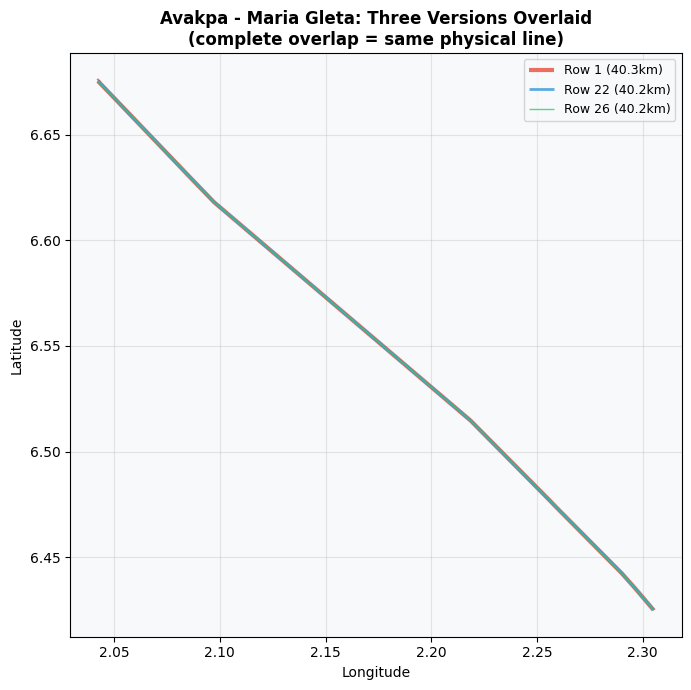

In [52]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = [f'Row {idx[0]} ({avakpa.iloc[0]["km"]}km)',
          f'Row {idx[1]} ({avakpa.iloc[1]["km"]}km)',
          f'Row {idx[2]} ({avakpa.iloc[2]["km"]}km)']

for i, (_, row) in enumerate(avakpa.iterrows()):
    gpd.GeoSeries([row['geometry']]).plot(
        ax=ax, color=colors[i], linewidth=3 - i,
        alpha=0.8, label=labels[i]
    )

ax.set_title('Avakpa - Maria Gleta: Three Versions Overlaid\n'
             '(complete overlap = same physical line)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [53]:
# All rows confirmed as redundant through geometric analysis
rows_to_remove = [19, 17, 34, 24, 18, 22, 26]

# Remove them and reset the index to be sequential from 0
grid_unique = grid.drop(index=rows_to_remove).reset_index(drop=True)

# Report the result
print(f"\n  Original grid:   {len(grid):>3} line segments")
print(f"  Removed:         {len(rows_to_remove):>3} duplicate segments")
print(f"  Clean grid:      {len(grid_unique):>3} unique line segments")
print(f"\n  Original length (inflated): {grid['km'].sum():.0f} km")
print(f"  Corrected length:           {grid_unique['km'].sum():.0f} km")

# Verify no duplicates remain
remaining = grid_unique[grid_unique.duplicated(subset=['Name', 'km'], keep=False)]
if len(remaining) == 0:
    print(f"\n No duplicate lines remain ")
else:
    print(f"\n  {len(remaining)} rows still flagged, review manually")
    display(remaining[['Name', 'Voltage_KV', 'km', 'From', 'To']])

# Remind which variable to use going forward
print(f"\n  grid: use for distance calculations ({len(grid)} segments)")
print(f"  grid_unique: use for length reporting ({len(grid_unique)} segments)")


  Original grid:    36 line segments
  Removed:           7 duplicate segments
  Clean grid:       29 unique line segments

  Original length (inflated): 2020 km
  Corrected length:           1515 km

 No duplicate lines remain 

  grid: use for distance calculations (36 segments)
  grid_unique: use for length reporting (29 segments)


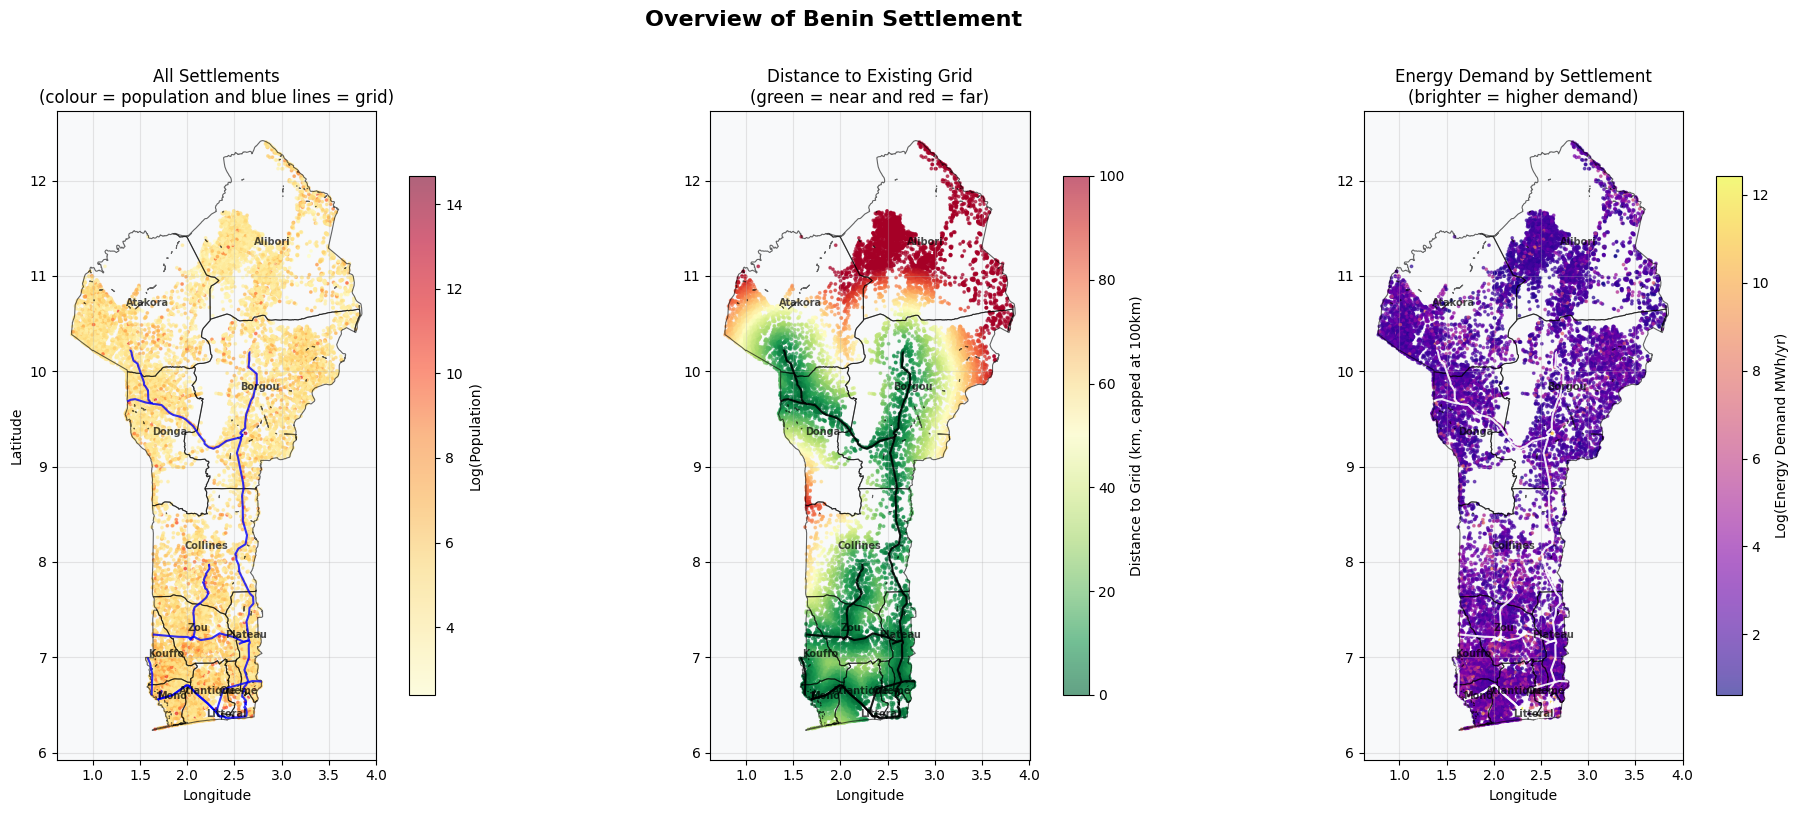

Map saved as 01_data_overview.png


In [77]:
# Plot maps with the clean data

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Overview of Benin Settlement',
             fontsize=16, fontweight='bold', y=1.01)

# Map1: Settlements coloured by population
# We use log(population) because a few huge cities would dominate the colour scale
# and make all small settlements look identical.
ax = axes[0]
# Add Benin province boundaries for geographic context
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
scatter = ax.scatter(
    settlements['lon'],
    settlements['lat'],
    c=np.log1p(settlements['population']),
    cmap='YlOrRd',    # yellow = small, red = large
    s=3,
    alpha=0.6
)
for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )
# Use grid_unique
grid_unique.plot(ax=ax, color='blue', linewidth=1.5, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Log(Population)', shrink=0.8)
ax.set_title('All Settlements\n(colour = population and blue lines = grid)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Map2: Settlements coloured by distance to grid
# clip(upper=100): anything beyond 100km shows as the same dark red
ax = axes[1]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
scatter2 = ax.scatter(
    settlements['lon'],
    settlements['lat'],
    c=settlements['distance_to_existing_transmission_lines'].clip(upper=100),
    cmap='RdYlGn_r',  # green = near grid, red = far
    s=3,
    alpha=0.6
)
for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )
grid_unique.plot(ax=ax, color='black', linewidth=1.5, alpha=0.9)
plt.colorbar(scatter2, ax=ax,
             label='Distance to Grid (km, capped at 100km)', shrink=0.8)
ax.set_title('Distance to Existing Grid\n(green = near and red = far)')
ax.set_xlabel('Longitude')

# Map3: Energy demand by settlement
# Used log because of the disparity in value range
ax = axes[2]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
scatter3 = ax.scatter(
    settlements['lon'],
    settlements['lat'],
    c=np.log1p(settlements['energy_demand']),
    cmap='plasma',    # dark purple = low demand, bright yellow = high
    s=3,
    alpha=0.6
)
for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )
grid_unique.plot(ax=ax, color='white', linewidth=1.5, alpha=0.9)
plt.colorbar(scatter3, ax=ax,
             label='Log(Energy Demand MWh/yr)', shrink=0.8)
ax.set_title('Energy Demand by Settlement\n(brighter = higher demand)')
ax.set_xlabel('Longitude')

plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved as 01_data_overview.png")

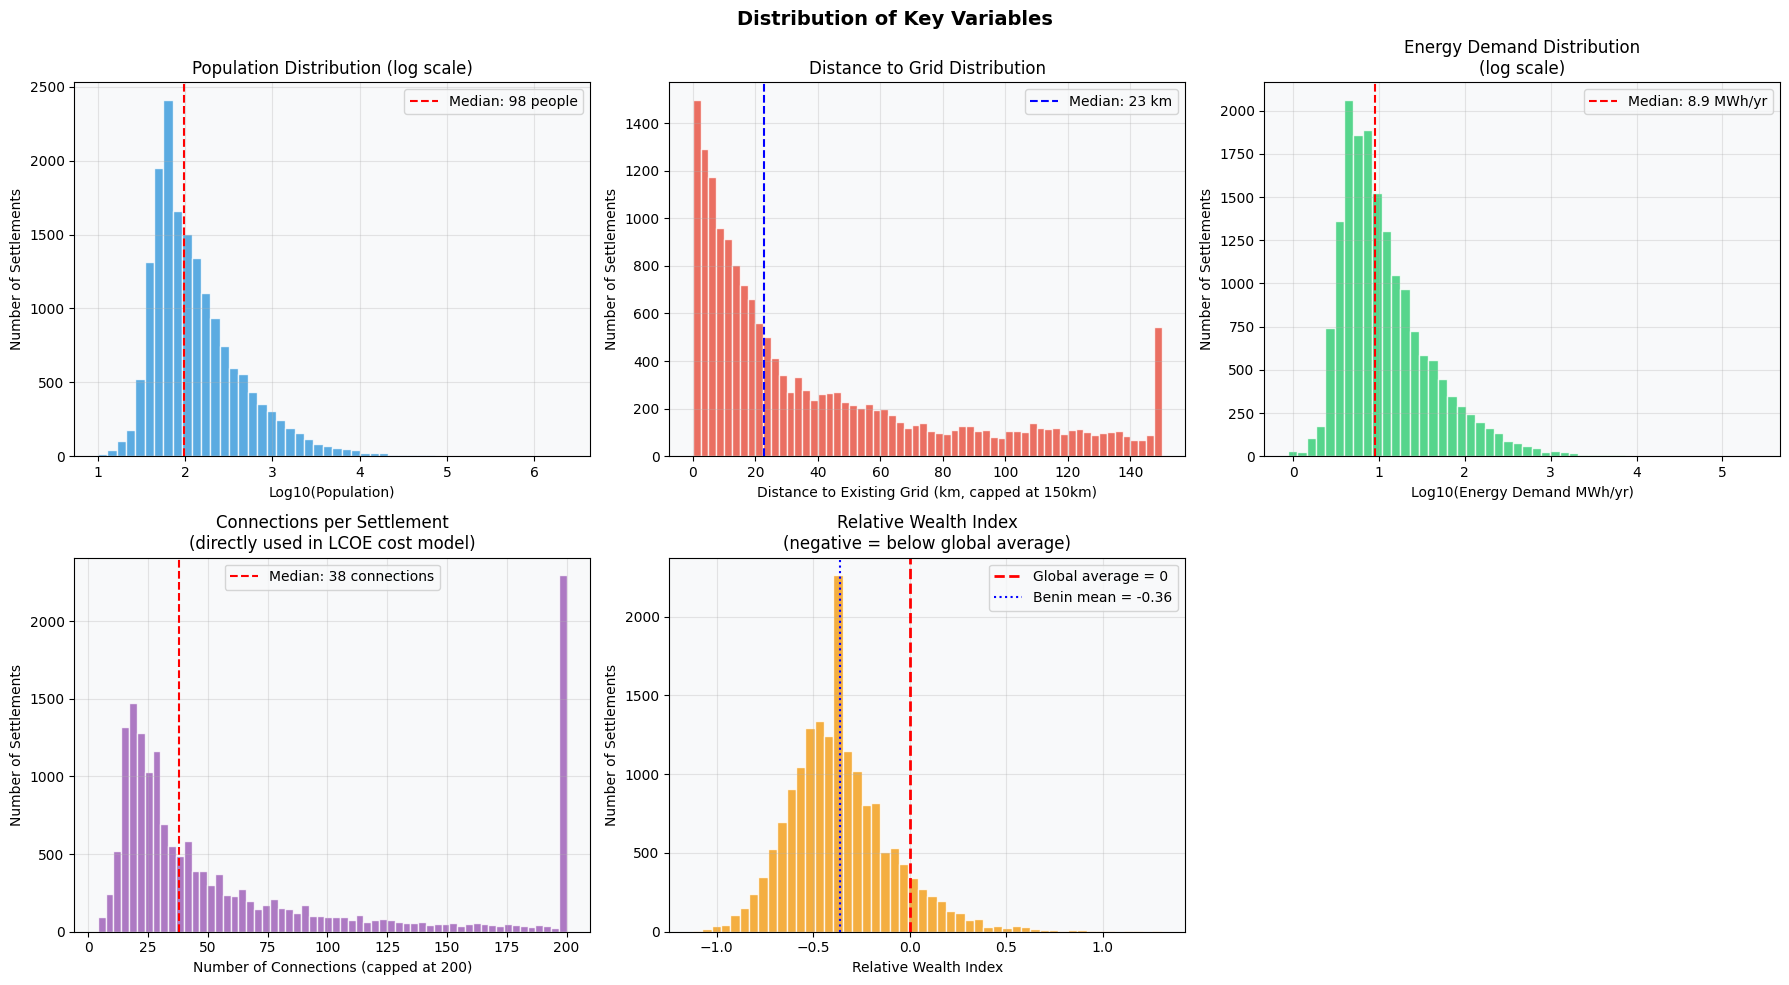

Distribution plots saved as 02_distributions.png


In [55]:
# Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Variables', fontsize=14, fontweight='bold')
# Hide the sixth subplot since we have 5 variables
axes[1, 2].set_visible(False)

# Population: Primary demand driver and used in prioritisation scoring
ax = axes[0, 0]
# Log scale because range spans 10 to 2.3 million people
ax.hist(np.log10(settlements['population'].clip(lower=1)),
        bins=50,              # number of bars in the histogram
        color='#3498db',      # blue bars
        edgecolor='white',    # white outline between bars for clarity
        alpha=0.8)            # slight transparency
# Red dashed line = median, shows where the middle settlement sits on the log scale
ax.axvline(np.log10(settlements['population'].median()),
           color='red',
           linestyle='--',
           label=f'Median: {settlements["population"].median():.0f} people')
ax.set_xlabel('Log10(Population)')
ax.set_ylabel('Number of Settlements')
ax.set_title('Population Distribution (log scale)')
ax.legend()  # Show the median label


# Distance to Grid: primary cost driver for grid extension LCOE
ax = axes[0, 1]
# full range would compress the main distribution, clip(upper=150) caps the x-axis at 150km
ax.hist(settlements['distance_to_existing_transmission_lines'].clip(upper=150),
        bins=60,
        color='#e74c3c',      # red - signals cost/difficulty
        edgecolor='white',
        alpha=0.8)

ax.axvline(settlements['distance_to_existing_transmission_lines'].median(),
           color='blue',
           linestyle='--',
           label=f'Median: {settlements["distance_to_existing_transmission_lines"].median():.0f} km')
ax.set_xlabel('Distance to Existing Grid (km, capped at 150km)')
ax.set_ylabel('Number of Settlements')
ax.set_title('Distance to Grid Distribution')
ax.legend()


# Energy Demand: direct input into all three LCOE functions
ax = axes[0, 2]
# clip(lower=0.1) prevents log(0) for any settlement with near-zero demand
ax.hist(np.log10(settlements['energy_demand'].clip(lower=0.1)),
        bins=50,
        color='#2ecc71',      # green - energy = positive
        edgecolor='white',
        alpha=0.8)
# Median on log scale- convert back so label shows actual MWh value
ax.axvline(np.log10(settlements['energy_demand'].median()),
           color='red',
           linestyle='--',
           label=f'Median: {settlements["energy_demand"].median():.1f} MWh/yr')
ax.set_xlabel('Log10(Energy Demand MWh/yr)')
ax.set_ylabel('Number of Settlements')
ax.set_title('Energy Demand Distribution\n(log scale)')
ax.legend()


# Number of Connections: Directly used in every LCOE function as n_households
# Determines connection CAPEX for all three technologies
ax = axes[1, 0]
ax.hist(settlements['num_connections'].clip(upper=200),
        bins=60, color='#9b59b6', edgecolor='white', alpha=0.8)
ax.axvline(settlements['num_connections'].median(),
           color='red', linestyle='--',
           label=f'Median: {settlements["num_connections"].median():.0f} connections')
ax.set_xlabel('Number of Connections (capped at 200)')
ax.set_ylabel('Number of Settlements')
ax.set_title('Connections per Settlement\n(directly used in LCOE cost model)')
ax.legend()


# Relative Wealth Index(RWI): used in prioritisation scoring
ax = axes[1, 1]
ax.hist(settlements['mean_rwi'], bins=50,
        color='#f39c12', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2,
           label='Global average = 0')
ax.axvline(settlements['mean_rwi'].mean(), color='blue', linestyle=':',
           label=f'Benin mean = {settlements["mean_rwi"].mean():.2f}')
ax.set_xlabel('Relative Wealth Index')
ax.set_ylabel('Number of Settlements')
ax.set_title('Relative Wealth Index\n(negative = below global average)')
ax.legend()


# Save and Display results
plt.tight_layout()
plt.savefig('02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plots saved as 02_distributions.png")

## Question 1: **How much electricity does each settlement need?**
### Demand estimation:
The dataset gives us Year 1 demand in the `energy_demand` column,
computed using the Multi-Tier Framework (MTF)- the SE4ALL standard
for measuring electricity access.

We project this forward over a **15-year** planning horizon using two parameters:
- **Demand Growth Rate**: how fast demand grows each year
- **Discount Rate**: how much less we value future costs compared to today



In [56]:
# Model Assumptions
print("CORE MODEL ASSUMPTIONS")

# 1. 15 year planning horizon - standard for Sub-Saharan Africa(SSA)
# PV modules last ~25 years, grid lines last ~30 years
PLANNING_HORIZON = 15

# 2. 3.5% Demand Growth Rate. Worked with 3 components
#    - Population growth:          ~2.7%/year (World Bank Benin, 2023)
#    - Income growth (appliances): ~1-2% demand uplift
#    - New connections ramping up: ~0.5%
#    - Combined:                   ~3.5-4.0% is appropriate for Benin
DEMAND_GROWTH_RATE = 0.035  # 3.5% per year

# 3: 8% Discount Rate.
#    - World Bank social discount rate for SSA infrastructure: 6-10%
DISCOUNT_RATE = 0.08  # 8% per year

print(f"\n  Planning horizon:   {PLANNING_HORIZON} years (2025 to {2025 + PLANNING_HORIZON})")
print(f"  Demand growth rate: {DEMAND_GROWTH_RATE * 100:.1f}% per year")
print(f"  Discount rate:      {DISCOUNT_RATE * 100:.1f}% per year")

# Future demand = Base demand × (1 + growth rate) ^ number of years
# Example using median settlement demand:
example_demand = settlements['energy_demand'].median()
year15 = example_demand * (1 + DEMAND_GROWTH_RATE) ** PLANNING_HORIZON

print(f"\n  Formula: D₁₅ = D₀ × (1 + g)^n")

def npv_factor(discount_rate, years):
    """
    Calculate the NPV annuity factor.

    This is a standard finance formula that converts a stream of
    identical annual payments into a single present value.

    Formula: (1 - (1 + r)^(-n)) / r

    Example: if r=8% and n=15:
    npv_factor = (1 - 1.08^-15) / 0.08 = 8.56
    This means $1/year for 15 years is worth $8.56 today

    Parameters:
    -----------
    discount_rate : float — e.g. 0.08 for 8%
    years         : int   — planning horizon

    Returns:
    --------
    float — the annuity factor
    """
    # Handle case where discount_rate is 0 to avoid division by zero
    if discount_rate == 0:
        return float(years) # If no discount, NPV factor is just the number of years
    return (1 - (1 + discount_rate) ** (-years)) / discount_rate


# Demand Estimation:
def present_value_demand(base_demand_mwh,
                          growth_rate=DEMAND_GROWTH_RATE,
                          discount_rate=DISCOUNT_RATE,
                          years=PLANNING_HORIZON):

    total = 0
    for t in range(years):
        # Demand in year t grows from base at compound rate
        demand_t = base_demand_mwh * (1 + growth_rate) ** t
        # Discount year t demand back to present value
        pv_t = demand_t / (1 + discount_rate) ** t
        total += pv_t
    return total


# Apply to Settlement Data
settlements['pv_demand_mwh'] = settlements['energy_demand'].apply(
    present_value_demand
)

# Year 15 demand
settlements['year15_demand_mwh'] = (
    settlements['energy_demand'] * (1 + DEMAND_GROWTH_RATE) ** PLANNING_HORIZON
)

# Results
print("Result")
print(f"\n  Total Year 1 demand:        {settlements['energy_demand'].sum():>12,.0f} MWh")
print(f"  Total Year 15 demand:       {settlements['year15_demand_mwh'].sum():>12,.0f} MWh")
print(f"  Growth over {PLANNING_HORIZON} years:      "
      f"+{((settlements['year15_demand_mwh'].sum()/settlements['energy_demand'].sum())-1)*100:.0f}%")
print(f"\n  Formula: D₁₅ = D₀ × (1 + {DEMAND_GROWTH_RATE})^{PLANNING_HORIZON}")
print(f"  Example (median settlement):")

median_d0  = settlements['energy_demand'].median()
median_d15 = median_d0 * (1 + DEMAND_GROWTH_RATE) ** PLANNING_HORIZON
median_pv  = present_value_demand(median_d0)

print(f"    D₀  = {median_d0:.1f} MWh/year")
print(f"    D₁₅ = {median_d15:.1f} MWh/year")
print(f"    PV of cumulative demand = {median_pv:.1f} MWh")

CORE MODEL ASSUMPTIONS

  Planning horizon:   15 years (2025 to 2040)
  Demand growth rate: 3.5% per year
  Discount rate:      8.0% per year

  Formula: D₁₅ = D₀ × (1 + g)^n
Result

  Total Year 1 demand:           1,409,633 MWh
  Total Year 15 demand:          2,361,628 MWh
  Growth over 15 years:      +68%

  Formula: D₁₅ = D₀ × (1 + 0.035)^15
  Example (median settlement):
    D₀  = 8.9 MWh/year
    D₁₅ = 14.9 MWh/year
    PV of cumulative demand = 100.8 MWh



## Question 2: **What is the cheapest way to provide the electricity?**

### Least-cost technology analysis
**Levelised Cost of Electricity (LCOE) formula:**
```
LCOE = Total Present Cost  ÷  Total Present Energy
     = (CAPEX + PV of OPEX) ÷ (PV of Energy Delivered)
```


In [57]:
# Define cost parameters
# All costs in USD. Sources cited for each assumption.
print("TECHNOLOGY COST PARAMETERS")

# GRID EXTENSION

# Cost to build 1km of medium-voltage line
# Reference:  World Bank ESMAP (2020): $15,000-$35,000/km for SSA
#             $20,000/km is the mid-point for moderate terrain
#             Northern Benin rocky terrain could reach $35,000/km
GRID_CAPEX_PER_KM = 20_000      # USD per km

# Cost to connect each household to the grid
# Reference:  AfDB Benin energy sector assessment: $300-700 per connection
GRID_HH_CONNECTION = 500        # USD per household

# Annual operations and maintenance as % of CAPEX
# Covers line maintenance, metering, billing, loss management
# Reference:  OnSSET model default parameters (onsset.readthedocs.io):  2%#
GRID_OPEX_RATE = 0.02           # 2% of CAPEX per year

# Technical losses in transmission and distribution
# Reference:  West Africa Power Pool: 10-15% losses for rural distribution
GRID_LOSSES = 0.12              # 12%

print("\n  GRID EXTENSION")
print(f"    Line construction:    ${GRID_CAPEX_PER_KM:,}/km")
print(f"    Household connection: ${GRID_HH_CONNECTION:,}/household")
print(f"    Annual O&M:           {GRID_OPEX_RATE*100:.0f}% of CAPEX/year")
print(f"    Technical losses:     {GRID_LOSSES*100:.0f}%")


# MINI-GRID

# Cost per kW of installed solar + battery capacity
# Reference:  IRENA Renewable Power Costs 2023:
#             Utility solar ~$900/kW + battery storage ~$800/kW
#             + inverters ~$200/kW + rural transport/install ~$600/kW
#             = $2,000-3,000/kW total for rural West Africa mini-grid
MG_CAPEX_PER_KW = 2_500         # USD per kW installed

# Household connection cost within the mini-grid service area
# Lower than grid extension because distribution distances are shorter
MG_HH_CONNECTION = 300          # USD per household

# Fraction of time the solar system produces at full rated capacity
# Benin solar resource: 5.0-5.5 peak sun hours/day (GlobalSolarAtlas)
# 1,750 kWh/kWp/year ÷ 8,760 hours = 20% raw
# Rounded to 25% to account for battery buffer and system oversizing
# Note: using national average, irradiance varies slightly north to south but variation is small across Benin
# Reference:  GlobalSolarAtlas PVOUT data for Benin
MG_CAPACITY_FACTOR = 0.25       # 25%

# Higher O&M than grid because of battery management requirements
MG_OPEX_RATE = 0.03             # 3% of CAPEX per year

print("\n  MINI-GRID (solar + battery)")
print(f"    System cost:          ${MG_CAPEX_PER_KW:,}/kW installed")
print(f"    Household connection: ${MG_HH_CONNECTION:,}/household")
print(f"    Capacity factor:      {MG_CAPACITY_FACTOR*100:.0f}%")
print(f"    Annual O&M:           {MG_OPEX_RATE*100:.0f}% of CAPEX/year")


# SOLAR HOME SYSTEM

# Cost of a 50Wp system providing Tier 2 service
# Reference:  GOGLA Market Data 2023: quality-verified 50Wp SHS = $150-250
#             $200 is the mid-point for a quality Tier 2 system with battery
SHS_CAPEX = 200                 # USD per system

# Annual maintenance with occasional repairs and component replacement
SHS_OPEX_ANNUAL = 15            # USD per system per year

# Battery replacement cycle
# Lithium-ion batteries last 5-8 years, 7 years is the mid-point estimate
SHS_BATTERY_LIFETIME = 7        # years

# Annual energy output
# Calculation: 50W × 5h sun/day × 365 days × 80% efficiency = 73 kWh/year
SHS_ENERGY_KWH_YEAR = 73        # kWh per system per year

print("\n  SOLAR HOME SYSTEM (50Wp, Tier 2)")
print(f"    System cost:          ${SHS_CAPEX:,}/system")
print(f"    Annual O&M:           ${SHS_OPEX_ANNUAL:,}/system/year")
print(f"    Battery lifetime:     {SHS_BATTERY_LIFETIME} years")
print(f"    Annual output:        {SHS_ENERGY_KWH_YEAR} kWh/year")
print(f"    Daily output:         {SHS_ENERGY_KWH_YEAR/365*1000:.0f} Wh/day")
print(f"    Service tier:         Tier 2: lighting, phone charging, radio, small fan")


TECHNOLOGY COST PARAMETERS

  GRID EXTENSION
    Line construction:    $20,000/km
    Household connection: $500/household
    Annual O&M:           2% of CAPEX/year
    Technical losses:     12%

  MINI-GRID (solar + battery)
    System cost:          $2,500/kW installed
    Household connection: $300/household
    Capacity factor:      25%
    Annual O&M:           3% of CAPEX/year

  SOLAR HOME SYSTEM (50Wp, Tier 2)
    System cost:          $200/system
    Annual O&M:           $15/system/year
    Battery lifetime:     7 years
    Annual output:        73 kWh/year
    Daily output:         200 Wh/day
    Service tier:         Tier 2: lighting, phone charging, radio, small fan


In [58]:
# LCOE FUNCTIONS/TECHNOLOGY

def lcoe_grid_extension(dist_km, n_households, annual_demand_mwh,
                         capex_km=GRID_CAPEX_PER_KM,
                         capex_hh=GRID_HH_CONNECTION,
                         opex_rate=GRID_OPEX_RATE,
                         losses=GRID_LOSSES,
                         discount=DISCOUNT_RATE,
                         years=PLANNING_HORIZON):
    """
    Compute LCOE for grid extension in USD/kWh.

    COST DRIVERS:
    - Distance to grid (the further, the more expensive the line is)
    - Number of households (determines connection CAPEX)

    FORMULA:
    LCOE = (Line CAPEX + Connection CAPEX + PV of OPEX)
           ÷ PV of Energy Delivered

    NOTE ON FIELD EXPERIENCE:
    This model uses flat-terrain cost assumptions.
    In northern Benin (Atakora Massif), rocky terrain can
    multiply per-km costs by 2-3x.
    """
    # Guard against invalid inputs
    if annual_demand_mwh <= 0 or n_households <= 0:
        return 9999  # Return very high number = not viable

    annual_demand_kwh = annual_demand_mwh * 1000  # Convert MWh to kWh

    # Calculate CAPEX
    line_cost = dist_km * capex_km                 # Cost to build the MV line
    connection_cost = n_households * capex_hh       # Cost to connect households
    total_capex = line_cost + connection_cost

    # Calculate PV of OPEX
    # OPEX is paid every year - convert to present value using NPV factor
    annual_opex = total_capex * opex_rate
    pv_opex = annual_opex * npv_factor(discount, years)

    # Total Present Cost
    total_cost = total_capex + pv_opex

    # PV of Energy Delivered
    # Not all electricity reaches customers (12% losses)
    energy_delivered = annual_demand_kwh * (1 - losses)
    pv_energy = energy_delivered * npv_factor(discount, years)

    # LCOE
    if pv_energy <= 0:
        return 9999
    return round(total_cost / pv_energy, 4)


def lcoe_mini_grid(n_households, annual_demand_mwh,
                   capex_kw=MG_CAPEX_PER_KW,
                   capex_hh=MG_HH_CONNECTION,
                   opex_rate=MG_OPEX_RATE,
                   capacity_factor=MG_CAPACITY_FACTOR,
                   discount=DISCOUNT_RATE,
                   years=PLANNING_HORIZON):
    """
    Compute LCOE for a solar mini-grid in USD/kWh.

    COST DRIVERS:
    - Annual demand (determines system size)
    - Number of households (distribution network within settlement)

    KEY INSIGHT:
    Mini-grid has NO distance penalty.
    The same cost applies whether the settlement is 5km or 200km from the grid.

    SYSTEM SIZING:
    Required kW = (Annual demand / capacity_factor / 8760 hours) × 1.3 safety
    The 1.3 factor accounts for: battery storage losses, inverter losses,
    peak demand above average, and system degradation over time.
    """
    if annual_demand_mwh <= 0 or n_households <= 0:
        return 9999

    annual_demand_kwh = annual_demand_mwh * 1000
    hours_per_year = 8760  # 365 days × 24 hours

    # Size the system: Average power needed = demand / hours
    # Installed capacity = average power / capacity_factor × safety_factor
    average_power_kw = annual_demand_kwh / hours_per_year
    system_kw = (average_power_kw / capacity_factor) * 1.3
    system_kw = max(system_kw, 1.0)  # Minimum 1 kW system

    # CAPEX
    generation_capex = system_kw * capex_kw     # Solar panels + batteries + inverter
    connection_capex = n_households * capex_hh   # Local distribution wiring
    total_capex = generation_capex + connection_capex

    # PV of OPEX
    annual_opex = total_capex * opex_rate
    pv_opex = annual_opex * npv_factor(discount, years)

    total_cost = total_capex + pv_opex

    # Energy produce: The system produces: kW × capacity_factor × hours/year
    annual_energy_produced = system_kw * capacity_factor * hours_per_year
    pv_energy = annual_energy_produced * npv_factor(discount, years)

    # LCOE
    if pv_energy <= 0:
        return 9999
    return round(total_cost / pv_energy, 4)


def lcoe_solar_home_system(n_households,
                            capex=SHS_CAPEX,
                            opex_annual=SHS_OPEX_ANNUAL,
                            battery_lifetime=SHS_BATTERY_LIFETIME,
                            energy_kwh=SHS_ENERGY_KWH_YEAR,
                            discount=DISCOUNT_RATE,
                            years=PLANNING_HORIZON):
    """
    Compute LCOE for Solar Home Systems in USD/kWh.

    SHS needs the battery replaced every 7 years.
    Over 15 years, you effectively buy the system TWICE.
    This battery replacement cost is discounted to present value.

    LIMITATION:
    SHS only provides Tier 2 service (73 kWh/year).
    It cannot power productive use loads (mills, cold storage, irrigation).
    This limits economic development potential compared to mini-grids.
    """
    if n_households <= 0:
        return 9999

    # CAPEX with replacements
    total_capex = n_households * capex  # Initial purchase

    # How many battery replacements in planning horizon?
    # e.g. 15 years / 7 year battery = 2 replacements (at year 7 and year 14)
    n_replacements = years // battery_lifetime

    for i in range(1, n_replacements + 1):
        replacement_year = i * battery_lifetime
        if replacement_year < years:
            # Discount the future replacement to present value
            # $200 in year 7 at 8% discount = $200 / (1.08^7) = $116.84 today
            pv_replacement = (n_households * capex) / (1 + discount) ** replacement_year
            total_capex += pv_replacement

    # PV of OPEX
    annual_opex = n_households * opex_annual
    pv_opex = annual_opex * npv_factor(discount, years)

    total_cost = total_capex + pv_opex

    # Energy delivered
    # Each SHS delivers fixed energy which does not grow with demand
    annual_energy = n_households * energy_kwh
    pv_energy = annual_energy * npv_factor(discount, years)

    # LCOE
    if pv_energy <= 0:
        return 9999
    return round(total_cost / pv_energy, 4)


# TEST: Print LCOE for a sample settlement
print("LCOE TEST for Settlement with 100 households, 10 MWh/year demand")
for dist in [0, 5, 10, 25, 50, 100]:
    lg = lcoe_grid_extension(dist, 100, 10)
    lm = lcoe_mini_grid(100, 10)
    ls = lcoe_solar_home_system(100)
    winner = min({'Grid': lg, 'Mini-Grid': lm, 'SHS': ls}, key=lambda k: {'Grid': lg, 'Mini-Grid': lm, 'SHS': ls}[k])
    print(f"  Dist={dist:3}km | Grid: ${lg:.3f} | Mini-grid: ${lm:.3f} | SHS: ${ls:.3f} | Winner: {winner}")

LCOE TEST for Settlement with 100 households, 10 MWh/year demand
  Dist=  0km | Grid: $0.777 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid
  Dist=  5km | Grid: $2.332 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid
  Dist= 10km | Grid: $3.887 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid
  Dist= 25km | Grid: $8.552 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid
  Dist= 50km | Grid: $16.326 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid
  Dist=100km | Grid: $31.875 | Mini-grid: $0.506 | SHS: $0.821 | Winner: Mini-Grid


## Question 3: **Which settlements should be prioritised for investment?** (Prioritisation)

In [59]:
# RUN THE LEAST-COST ANALYSIS For each of the 17,205 settlements:
# 1. Compute LCOE for grid extension, mini-grid, and SHS
# 2. Assign the technology with the lowest LCOE

print("Running least-cost analysis on 17,205 settlements")
lcoe_results = []

for idx, row in settlements.iterrows():

    # Extract the variables we need for each settlement
    n_hh = max(int(row['num_connections']), 1)  # Number of households
    dist_km = float(row['distance_to_existing_transmission_lines'])  # Distance to grid
    demand_mwh = float(row['energy_demand'])  # Annual demand in MWh

    # Compute LCOE for each technology
    lg = lcoe_grid_extension(dist_km, n_hh, demand_mwh)
    lm = lcoe_mini_grid(n_hh, demand_mwh)
    ls = lcoe_solar_home_system(n_hh)

    # Create a dictionary of options and find the cheapest
    options = {
        'Grid Extension':    lg,
        'Mini-Grid':         lm,
        'Solar Home System': ls
    }

    best_technology = min(options, key=options.get)  # Key with lowest value
    best_lcoe = options[best_technology]

    lcoe_results.append({
        'lcoe_grid':    lg,
        'lcoe_mg':      lm,
        'lcoe_shs':     ls,
        'technology':   best_technology,
        'lcoe_best':    best_lcoe
    })

# This prevents duplicate columns if the cell is run more than once
result_cols = ['lcoe_grid', 'lcoe_mg', 'lcoe_shs', 'technology', 'lcoe_best']
settlements = settlements.drop(
    columns=[c for c in result_cols if c in settlements.columns])

# Combine results with the original settlements dataframe
results_df = pd.DataFrame(lcoe_results)
settlements = pd.concat([settlements.reset_index(drop=True), results_df], axis=1)

tc = settlements['technology'].value_counts()
tp = settlements.groupby('technology')['population'].sum()
td = settlements.groupby('technology')['energy_demand'].sum()
tl = settlements.groupby('technology')['lcoe_best'].mean()

print(f"\n{'Technology':<22} {'Settlements':>12} {'Population':>12} {'Demand MWh/yr':>15} {'Avg LCOE':>10}")
print("-" * 73)
for tech in tc.index:
    print(f"{tech:<22} {tc[tech]:>12,} {tp.get(tech,0):>12,} {td.get(tech,0):>14,.0f} ${tl.get(tech,0):>8.3f}")
print("-" * 73)
print(f"{'TOTAL':<22} {len(settlements):>12,} {settlements['population'].sum():>12,} {settlements['energy_demand'].sum():>14,.0f}")

Running least-cost analysis on 17,205 settlements

Technology              Settlements   Population   Demand MWh/yr   Avg LCOE
-------------------------------------------------------------------------
Mini-Grid                    17,026    6,449,554        596,655 $   0.314
Grid Extension                  179    7,661,638        812,979 $   0.245
-------------------------------------------------------------------------
TOTAL                        17,205   14,111,192      1,409,633


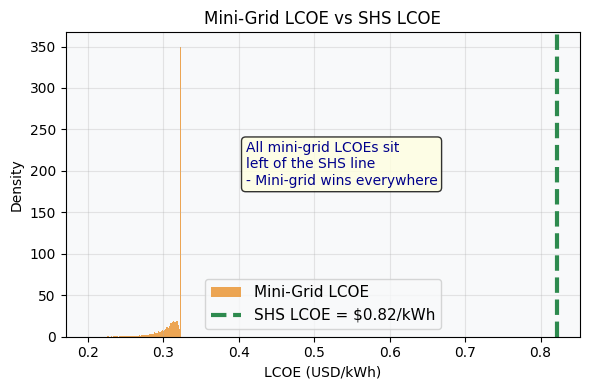

In [60]:
# Visual confirmation
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(settlements['lcoe_mg'], bins=80, alpha=0.7,
        color=TECH_COLORS['Mini-Grid'],
        label='Mini-Grid LCOE', density=True)

ax.axvline(settlements['lcoe_shs'].mean(),
           color=TECH_COLORS['Solar Home System'],
           linewidth=3, linestyle='--',
           label=f'SHS LCOE = ${settlements["lcoe_shs"].mean():.2f}/kWh')

ax.annotate(
    'All mini-grid LCOEs sit\nleft of the SHS line\n- Mini-grid wins everywhere',
    xy=(0.35, 0.5), xycoords='axes fraction',
    fontsize=10, color='darkblue',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax.set_xlabel('LCOE (USD/kWh)')
ax.set_ylabel('Density')
ax.set_title('Mini-Grid LCOE vs SHS LCOE')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('06_shs_vs_mg.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# Mini-grid LCOE ($0.20-0.32/kWh) beats SHS ($0.82/kWh) for every settlement because:
# 1. Shared generation infrastructure is more efficient than
#    individual systems at settlement-level demand
# 2. SHS battery replacement every 7 years adds significant
#    cost over the 15-year planning horizon
# 3. Even small settlements have enough demand that a shared
#    mini-grid outperforms standalone systems
# Reference: IRENA (2023): mini-grid LCOE now competitive with SHS
#                          when demand exceeds ~50 kWh/year

print(f"SHS LCOE:        ${settlements['lcoe_shs'].mean():.3f}/kWh (same for all settlements)")
print(f"Mini-Grid range: ${settlements['lcoe_mg'].min():.3f} - ${settlements['lcoe_mg'].max():.3f}/kWh")
print(f"Mini-grid is cheaper than SHS for all {len(settlements):,} settlements")
print(f"SHS remains appropriate for isolated dwellings not in settlement boundaries")


SHS LCOE:        $0.821/kWh (same for all settlements)
Mini-Grid range: $0.201 - $0.324/kWh
Mini-grid is cheaper than SHS for all 17,205 settlements
SHS remains appropriate for isolated dwellings not in settlement boundaries


## Visualisations: Maps and Charts

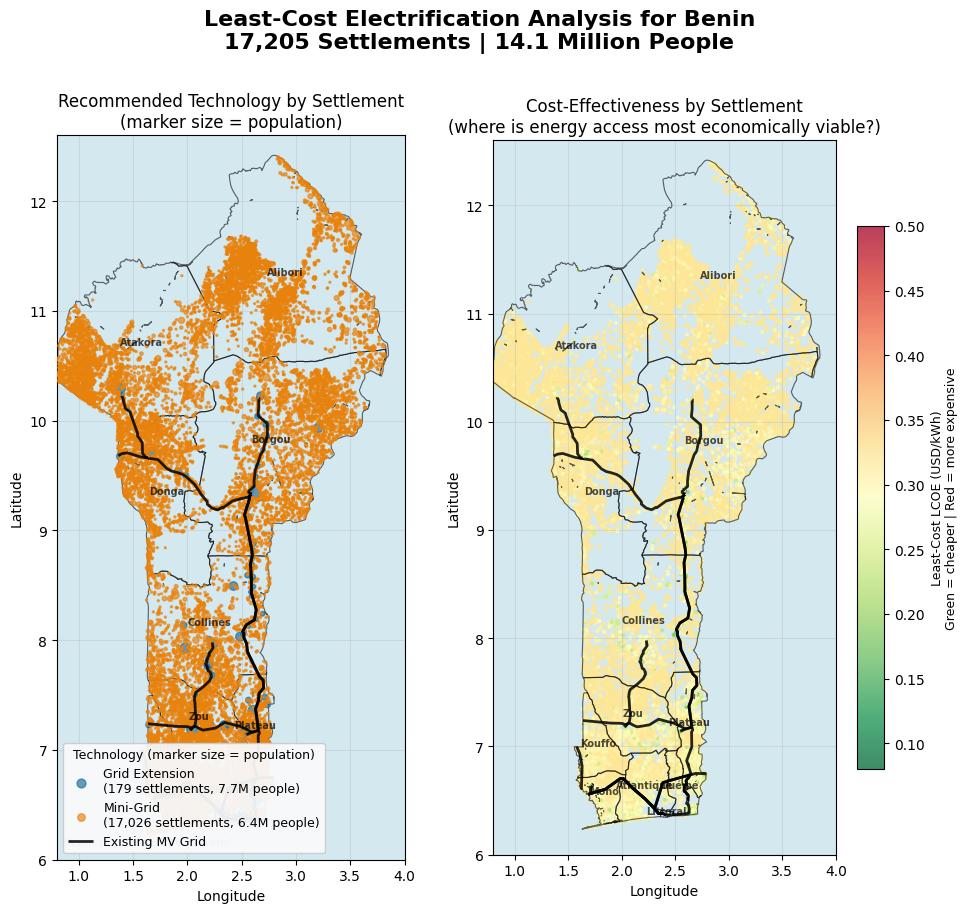

Main technology map saved as 07_main_technology_map.png


In [62]:
benin_provinces = gpd.read_file(
    '/content/drive/My Drive/Lilian_Sudi_VIDA_Benin_Case_Study/gadm41_BEN_1.json'
)
# The primary output
fig, axes = plt.subplots(1, 2, figsize=(10, 9))
plt.subplots_adjust(wspace=0.03)
fig.suptitle('Least-Cost Electrification Analysis for Benin\n17,205 Settlements | 14.1 Million People',
             fontsize=16, fontweight='bold', y=1.01)

# Map 1: Technology zones
ax = axes[0]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
ax.set_facecolor('#d4e8f0')

for tech, color in TECH_COLORS.items():
    subset = settlements[settlements['technology'] == tech]
    if len(subset) > 0:
        # Scale marker size by population (square root to avoid huge dots)
        sizes = np.clip(np.sqrt(subset['population']) / 5, 2, 80)
        ax.scatter(subset['lon'], subset['lat'],
                   c=color, s=sizes, alpha=0.65, zorder=3,
                   label=f'{tech}\n({len(subset):,} settlements, {subset["population"].sum()/1e6:.1f}M people)')

# Add province name at the centroid of each province
for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )

# Draw grid lines
grid.plot(ax=ax, color='black', linewidth=2, alpha=0.85, zorder=5, label='Existing MV Grid')

ax.set_title('Recommended Technology by Settlement\n(marker size = population)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
legend = ax.legend(loc='lower left', fontsize=9, framealpha=0.95,
                   title='Technology (marker size = population)', title_fontsize=9)
ax.set_xlim([0.8, 4.0])
ax.set_ylim([6.0, 12.6])
ax.grid(True, alpha=0.3)

# Add scale reference
ax.annotate('Benin total area: 114,763 km²', xy=(0.02, 0.02), xycoords='axes fraction',
            fontsize=8, color='grey', style='italic')

# Map 2: LCOE heatmap
ax = axes[1]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
ax.set_facecolor('#d4e8f0')

sc = ax.scatter(
    settlements['lon'], settlements['lat'],
    c=settlements['lcoe_best'].clip(upper=0.5),
    cmap='RdYlGn_r',  # Red = expensive, Green = cheap
    s=4, alpha=0.75,
    vmin=0.08, vmax=0.50
)

for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )
grid.plot(ax=ax, color='black', linewidth=2, alpha=0.85, zorder=5)

cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label('Least-Cost LCOE (USD/kWh)\nGreen = cheaper | Red = more expensive',
               fontsize=9)

ax.set_title('Cost-Effectiveness by Settlement\n(where is energy access most economically viable?)',
             fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim([0.8, 4.0])
ax.set_ylim([6.0, 12.6])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('07_main_technology_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Main technology map saved as 07_main_technology_map.png")

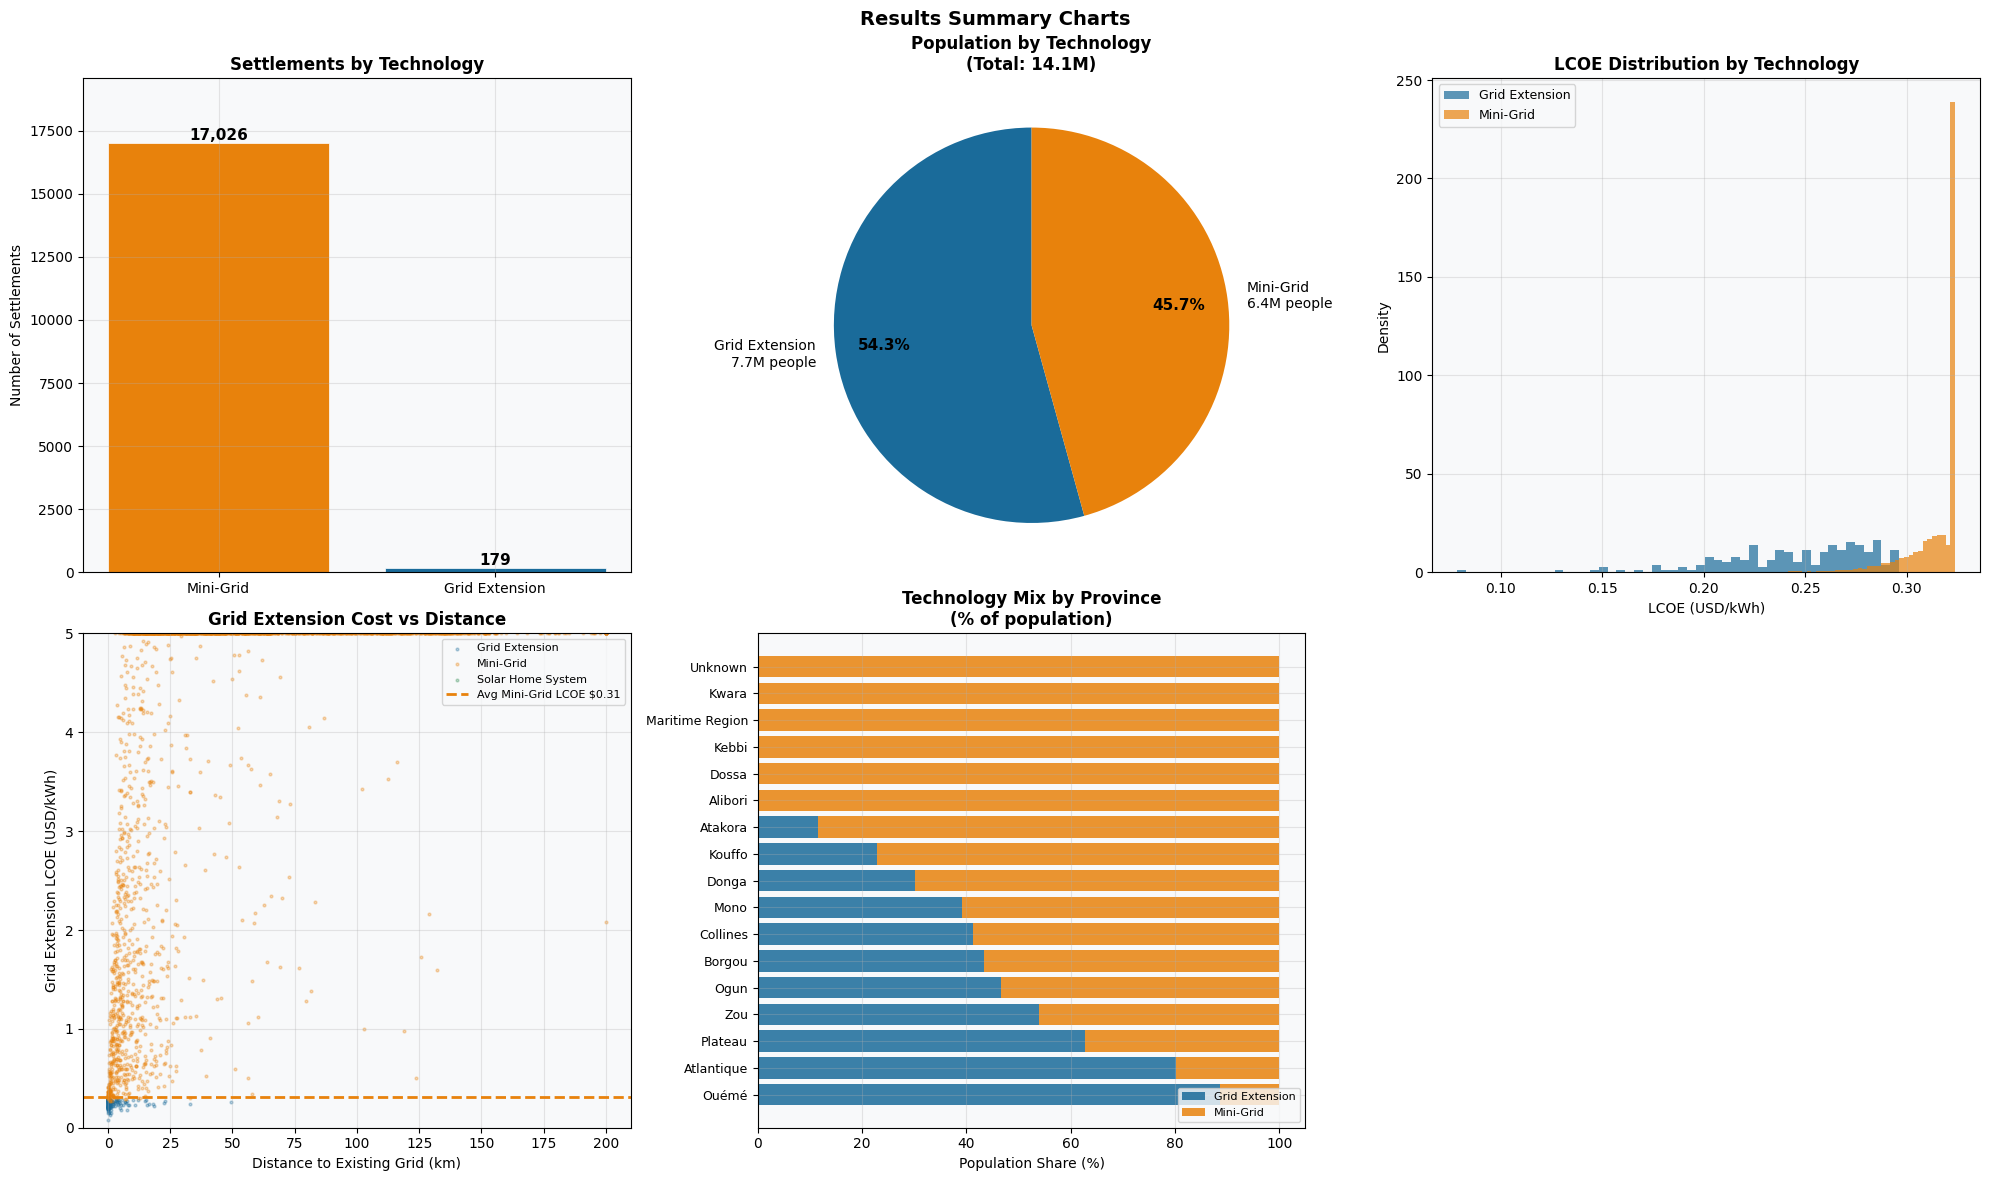

Results summary saved as 08_results_summary.png


In [63]:
# Summary Charts

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Results Summary Charts', fontsize=14, fontweight='bold')

# Chart 1: Settlement count by technology
ax = axes[0, 0]
tc = settlements['technology'].value_counts()
bars = ax.bar(tc.index, tc.values,
              color=[TECH_COLORS[t] for t in tc.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, tc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Settlements by Technology', fontweight='bold')
ax.set_ylabel('Number of Settlements')
ax.set_ylim(0, max(tc.values) * 1.15)

# Chart 2: Population by technology (pie)
ax = axes[0, 1]
tp = settlements.groupby('technology')['population'].sum()
wedges, texts, autotexts = ax.pie(
    tp.values,
    labels=[f'{t}\n{v/1e6:.1f}M people' for t, v in tp.items()],
    colors=[TECH_COLORS[t] for t in tp.index],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title(f'Population by Technology\n(Total: {tp.sum()/1e6:.1f}M)', fontweight='bold')

# Chart 3: LCOE distribution
ax = axes[0, 2]
for tech, color in TECH_COLORS.items():
    sub = settlements[settlements['technology'] == tech]
    if len(sub) > 0:
        ax.hist(sub['lcoe_best'].clip(upper=1.0), bins=50, alpha=0.7,
                color=color, label=tech, density=True)
ax.set_xlabel('LCOE (USD/kWh)')
ax.set_ylabel('Density')
ax.set_title('LCOE Distribution by Technology', fontweight='bold')
ax.legend(fontsize=9)

# Chart 4: Grid LCOE vs distance
ax = axes[1, 0]
for tech, color in TECH_COLORS.items():
    sub = settlements[settlements['technology'] == tech].sample(min(2000, len(settlements[settlements['technology']==tech])))
    ax.scatter(sub['distance_to_existing_transmission_lines'].clip(upper=200),
               sub['lcoe_grid'].clip(upper=5),
               c=color, s=4, alpha=0.3, label=tech)
ax.axhline(settlements['lcoe_mg'].mean(), color=TECH_COLORS['Mini-Grid'],
           linewidth=2, linestyle='--',
           label=f'Avg Mini-Grid LCOE ${settlements["lcoe_mg"].mean():.2f}')
ax.set_xlabel('Distance to Existing Grid (km)')
ax.set_ylabel('Grid Extension LCOE (USD/kWh)')
ax.set_title('Grid Extension Cost vs Distance', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 5)

# Chart 5: Population by province and technology
ax = axes[1, 1]
province_tech = settlements.groupby(['admin_cgaz_1', 'technology'])['population'].sum().unstack(fill_value=0)
province_tech_pct = province_tech.div(province_tech.sum(axis=1), axis=0) * 100
province_tech_pct = province_tech_pct.sort_values('Grid Extension', ascending=False)

bottom = np.zeros(len(province_tech_pct))
for tech in ['Grid Extension', 'Mini-Grid', 'Solar Home System']:
    if tech in province_tech_pct.columns:
        values = province_tech_pct[tech].values
        ax.barh(range(len(province_tech_pct)), values, left=bottom,
                color=TECH_COLORS[tech], label=tech, alpha=0.85)
        bottom += values

ax.set_yticks(range(len(province_tech_pct)))
ax.set_yticklabels(province_tech_pct.index, fontsize=9)
ax.set_xlabel('Population Share (%)')
ax.set_title('Technology Mix by Province\n(% of population)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.savefig('08_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results summary saved as 08_results_summary.png")

## Sensitivity Analysis

**I test 6 scenarios** covering the most uncertain parameters.

In [64]:
# Define scenarios
# Each scenario changes one or more cost parameters from the base case
scenarios = [
    {
        'name': 'Base Case',
        'description': 'Our central assumptions',
        'grid_km':  20_000,   # USD/km
        'mg_kw':    2_500,    # USD/kW
        'discount': 0.08,     # 8%
        'use_planned': False,
        'color': '#555555'
    },
    {
        'name': 'High Grid Cost',
        'description': '+75% grid cost- rocky/difficult terrain in north Benin',
        'grid_km':  35_000,   # More expensive in difficult terrain
        'mg_kw':    2_500,
        'discount': 0.08,
        'use_planned': False,
        'color': '#e74c3c'
    },
    {
        'name': 'Low MG Cost (2030)',
        'description': '-40% mini-grid cost- IRENA projects solar cost reductions',
        'grid_km':  20_000,
        'mg_kw':    1_500,    # Cheaper by 2030 based on IRENA projections
        'discount': 0.08,
        'use_planned': False,
        'color': '#2ecc71'
    },
    {
        'name': 'High Discount 12%',
        'description': 'Commercial finance with country risk premium',
        'grid_km':  20_000,
        'mg_kw':    2_500,
        'discount': 0.12,     # Higher risk = higher discount rate
        'use_planned': False,
        'color': '#9b59b6'
    },
    {
        'name': 'Low Discount 5%',
        'description': 'Concessional/grant finance available',
        'grid_km':  20_000,
        'mg_kw':    2_500,
        'discount': 0.05,     # Softer finance = lower discount rate
        'use_planned': False,
        'color': '#3498db'
    },
    {
        'name': 'With Planned Grid',
        'description': 'Using planned transmission lines as grid proximity measure',
        'grid_km':  20_000,
        'mg_kw':    2_500,
        'discount': 0.08,
        'use_planned': True,  # Use planned grid distance instead of existing
        'color': '#f39c12'
    },
]

print("Running sensitivity analysis across 6 scenarios...")
sensitivity_results = []

for sc in scenarios:
    counts = {'Grid Extension': 0, 'Mini-Grid': 0, 'Solar Home System': 0}
    populations = {'Grid Extension': 0, 'Mini-Grid': 0, 'Solar Home System': 0}

    for _, row in settlements.iterrows():
        n_hh = max(int(row['num_connections']), 1)
        demand_mwh = float(row['energy_demand'])

        # Choose distance column based on scenario
        if sc['use_planned']:
            dist = float(row['dist_to_existing_planned_transmission_lines_2017'])
        else:
            dist = float(row['distance_to_existing_transmission_lines'])

        # Recompute LCOE with scenario parameters
        lg = lcoe_grid_extension(dist, n_hh, demand_mwh,
                                  capex_km=sc['grid_km'],
                                  discount=sc['discount'])
        lm = lcoe_mini_grid(n_hh, demand_mwh,
                             capex_kw=sc['mg_kw'],
                             discount=sc['discount'])
        ls = lcoe_solar_home_system(n_hh, discount=sc['discount'])

        options = {'Grid Extension': lg, 'Mini-Grid': lm, 'Solar Home System': ls}
        best = min(options, key=options.get)
        counts[best] += 1
        populations[best] += int(row['population'])

    sensitivity_results.append({
        'Scenario': sc['name'],
        'Description': sc['description'],
        'Grid Settlements': counts['Grid Extension'],
        'MG Settlements': counts['Mini-Grid'],
        'SHS Settlements': counts['Solar Home System'],
        'Grid Pop (M)': round(populations['Grid Extension'] / 1e6, 2),
        'MG Pop (M)': round(populations['Mini-Grid'] / 1e6, 2),
        'SHS Pop (M)': round(populations['Solar Home System'] / 1e6, 2)
    })
    print(f" {sc['name']}: Grid={counts['Grid Extension']:,}, MG={counts['Mini-Grid']:,}, SHS={counts['Solar Home System']}")

sens_df = pd.DataFrame(sensitivity_results)
print()
print("SENSITIVITY ANALYSIS RESULTS")
print(sens_df[['Scenario', 'Grid Settlements', 'MG Settlements', 'SHS Settlements',
               'Grid Pop (M)', 'MG Pop (M)']].to_string(index=False))


Running sensitivity analysis across 6 scenarios...
 Base Case: Grid=179, MG=17,026, SHS=0
 High Grid Cost: Grid=142, MG=17,063, SHS=0
 Low MG Cost (2030): Grid=6, MG=17,199, SHS=0
 High Discount 12%: Grid=164, MG=17,041, SHS=0
 Low Discount 5%: Grid=198, MG=17,007, SHS=0
 With Planned Grid: Grid=221, MG=16,984, SHS=0

SENSITIVITY ANALYSIS RESULTS
          Scenario  Grid Settlements  MG Settlements  SHS Settlements  Grid Pop (M)  MG Pop (M)
         Base Case               179           17026                0          7.66        6.45
    High Grid Cost               142           17063                0          7.35        6.76
Low MG Cost (2030)                 6           17199                0          0.10       14.02
 High Discount 12%               164           17041                0          7.58        6.53
   Low Discount 5%               198           17007                0          7.73        6.38
 With Planned Grid               221           16984                0      

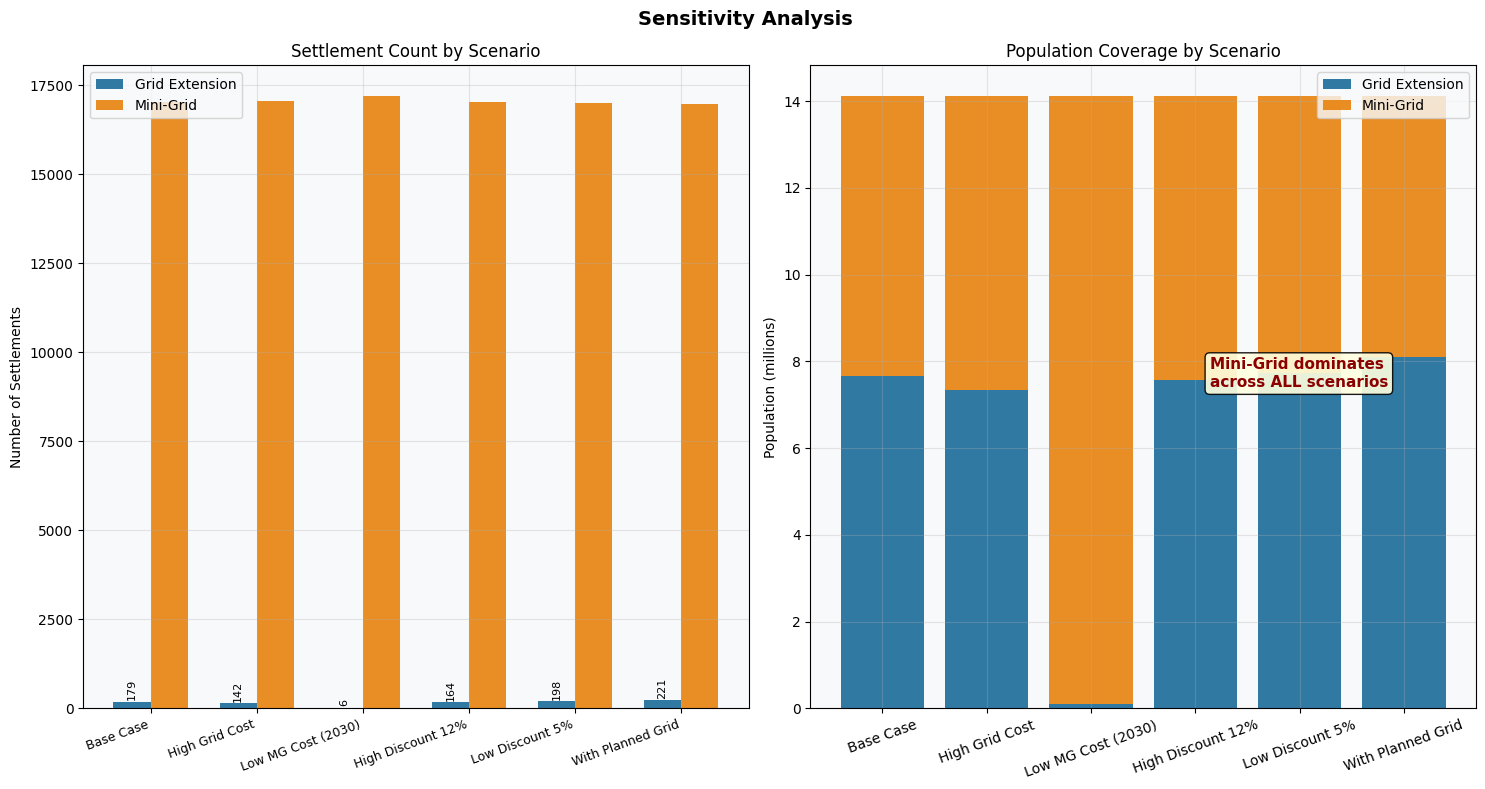

 Sensitivity analysis saved as 09_sensitivity_analysis.png


In [65]:
# Sensitivity Analysis Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Sensitivity Analysis',
             fontsize=14, fontweight='bold')

# Chart 1: Settlement count by scenario
ax = axes[0]
x = np.arange(len(sens_df))
w = 0.35

bars1 = ax.bar(x - w/2, sens_df['Grid Settlements'], w,
               color=TECH_COLORS['Grid Extension'], label='Grid Extension', alpha=0.9)
bars2 = ax.bar(x + w/2, sens_df['MG Settlements'], w,
               color=TECH_COLORS['Mini-Grid'], label='Mini-Grid', alpha=0.9)

# Add value labels on bars
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{bar.get_height():,.0f}', ha='center', fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(sens_df['Scenario'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Number of Settlements')
ax.set_title('Settlement Count by Scenario')
ax.legend()

# Chart 2: Population by scenario (stacked bar)
ax = axes[1]
ax.bar(sens_df['Scenario'], sens_df['Grid Pop (M)'],
       color=TECH_COLORS['Grid Extension'], label='Grid Extension', alpha=0.9)
ax.bar(sens_df['Scenario'], sens_df['MG Pop (M)'],
       bottom=sens_df['Grid Pop (M)'],
       color=TECH_COLORS['Mini-Grid'], label='Mini-Grid', alpha=0.9)

ax.set_ylabel('Population (millions)')
ax.set_title('Population Coverage by Scenario')
ax.tick_params(axis='x', rotation=20)
ax.legend()

# Add annotation highlighting the key finding
ax.annotate('Mini-Grid dominates\nacross ALL scenarios',
            xy=(0.6, 0.5), xycoords='axes fraction',
            fontsize=11, color='darkred', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('09_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sensitivity analysis saved as 09_sensitivity_analysis.png")


## Settlement Prioritisation

In [66]:
# Pioritisation criteria

# WEIGHT JUSTIFICATION:
#
# Population (35%)- highest weight because:
#   Maximising people reached per dollar invested is the
#   primary objective of national electrification planning
#   Reference:   World Bank ESMAP (2020): population served is the
#                primary metric for electrification programme evaluation
#                IEA Africa Energy Outlook (2022): SDG7 targets are
#                measured in population with access, not settlements
#
# Cost-effectiveness (30%)- second highest because:
#   Limited public finance must go where it delivers most
#   energy access per dollar
#   Reference:  OnSSET methodology: LCOE is the primary selection
#               criterion for technology and settlement prioritisation
#
# Social services (20%)- third because:
#   Health centres and schools are anchor loads that improve mini-grid viability
#   Reference:  SE4ALL MTF: presence of productive/social anchor
#               loads is a key viability indicator for mini-grids
#               AfDB (2019): electrifying health and education
#               facilities is an explicit Benin energy sector target
#
# Poverty/need (15%)- lowest weight because:
#   Poorer communities have greater need but also lower ability to pay
#   Reference:  World Bank ESMAP (2020): RWI-weighted prioritisation
#               must be balanced against financial sustainability
#
# WEIGHTS SUM TO 100%
print("PRIORITISATION SCORING")

WEIGHT_POPULATION = 35   # Population served- primary SDG7 metric
WEIGHT_SOCIAL     = 20   # Anchor loads- viability and welfare impact
WEIGHT_COST_EFF   = 30   # LCOE- value for money
WEIGHT_POVERTY    = 15   # RWI- need, balanced against ability to pay

print(f"\n  Population weight:      {WEIGHT_POPULATION}%  (SDG7 primary metric)")
print(f"  Cost-effectiveness:     {WEIGHT_COST_EFF}%  (OnSSET least-cost principle)")
print(f"  Social services weight: {WEIGHT_SOCIAL}%  (anchor loads + welfare impact)")
print(f"  Poverty/need:           {WEIGHT_POVERTY}%  (need vs ability to pay)")
print(f"  Total:                  {WEIGHT_POPULATION+WEIGHT_SOCIAL+WEIGHT_COST_EFF+WEIGHT_POVERTY}%")

# Normalise criteria to 0-1 scale

# 1. Population score: larger settlement = higher score
pop_score = settlements['population'] / settlements['population'].max()

# 2. Social services score: 0, 0.5, or 1
#    0   = no health or education facility
#    0.5 = one type of facility present
#    1.0 = both health AND education facility present
social_score = (
    settlements['has_health_facility'].astype(int) * 0.5 +
    settlements['has_education_facility'].astype(int) * 0.5
)

# 3. Cost-effectiveness score: lower LCOE = higher score
#    clip(upper=2). Formula: (max - value) / (max - min) = 1 = cheapest, 0 = most expensive
lcoe_max   = settlements['lcoe_best'].clip(upper=2).max()
lcoe_min   = settlements['lcoe_best'].min()
cost_score = (lcoe_max - settlements['lcoe_best'].clip(upper=2)) / (lcoe_max - lcoe_min)

# 4. Poverty score: more negative RWI = poorer = higher need = higher score
#    We invert RWI so the poorest settlement scores 1.0
#    Formula: (max - value) / (max - min) = 1 = poorest, 0 = wealthiest
rwi_min       = settlements['mean_rwi'].min()
rwi_max       = settlements['mean_rwi'].max()
poverty_score = (rwi_max - settlements['mean_rwi']) / (rwi_max - rwi_min)

# Combine into final score
settlements['priority_score'] = (
    pop_score     * WEIGHT_POPULATION +
    social_score  * WEIGHT_SOCIAL     +
    cost_score    * WEIGHT_COST_EFF   +
    poverty_score * WEIGHT_POVERTY
)

# Rank settlements from highest to lowest priority
settlements['priority_rank'] = settlements['priority_score'].rank(
    ascending=False).astype(int)

print(f"\nTop 15 Priority Settlements:")
top15 = settlements.nlargest(15, 'priority_score')[[
    'priority_rank', 'village_name', 'admin_cgaz_1', 'population',
    'technology', 'lcoe_best', 'has_health_facility',
    'has_education_facility', 'priority_score'
]].round(3)
display(top15)

PRIORITISATION SCORING

  Population weight:      35%  (SDG7 primary metric)
  Cost-effectiveness:     30%  (OnSSET least-cost principle)
  Social services weight: 20%  (anchor loads + welfare impact)
  Poverty/need:           15%  (need vs ability to pay)
  Total:                  100%

Top 15 Priority Settlements:


,priority_rank,village_name,admin_cgaz_1,population,technology,lcoe_best,has_health_facility,has_education_facility,priority_score
17175,1,Togba,Atlantique,2348441,Grid Extension,0.217,True,True,72.860
5423,2,Akpro-Missérété,Ouémé,1019945,Grid Extension,0.218,True,True,52.574
1356,3,Savè,Collines,1281,Grid Extension,0.146,True,True,49.554
637,4,Parakou,Borgou,409401,Grid Extension,0.201,True,True,47.588
3584,5,Kétou,Plateau,52644,Grid Extension,0.167,True,True,46.661
3765,6,Kétou,Plateau,13470,Grid Extension,0.174,True,True,46.154
12588,7,Savè,Collines,41482,Grid Extension,0.176,True,True,45.277
7695,8,Bohicon,Zou,616409,Grid Extension,0.237,True,True,45.260
14542,9,Tchaourou,Borgou,28008,Grid Extension,0.199,True,True,44.533
10162,10,Kétou,Plateau,8549,Grid Extension,0.182,True,True,44.379


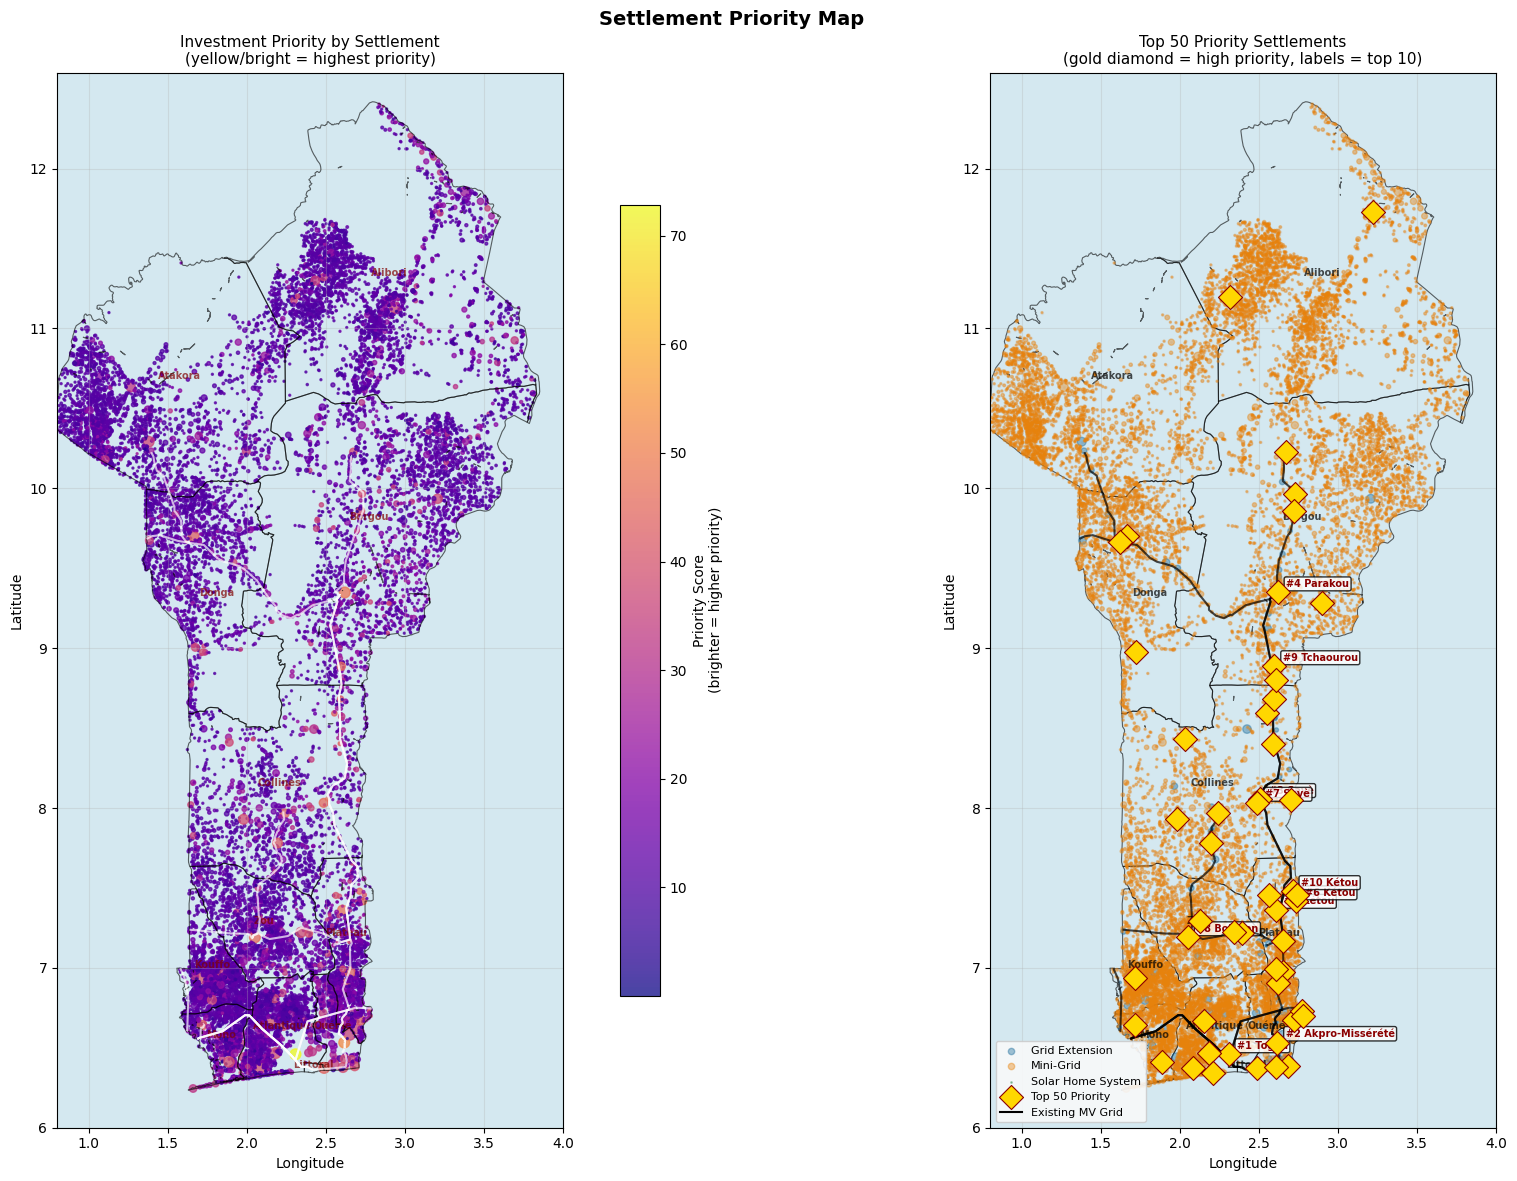

Priority map saved as 10_priority_map.png


In [75]:
# Priority Map

fig, axes = plt.subplots(1, 2, figsize=(22, 12))
fig.suptitle('Settlement Priority Map',
             fontsize=14, fontweight='bold')

# Map 1: All settlements coloured by priority score
ax = axes[0]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
ax.set_facecolor('#d4e8f0')

sc = ax.scatter(
    settlements['lon'], settlements['lat'],
    c=settlements['priority_score'],
    cmap='plasma',  # Dark purple = low, bright yellow = high priority
    s=np.clip(np.sqrt(settlements['population'])/5, 2, 60),
    alpha=0.75
)
for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='maroon',
        fontweight='bold',
        alpha=0.7
    )
grid.plot(ax=ax, color='white', linewidth=1.5, alpha=0.7, zorder=5)
plt.colorbar(sc, ax=ax, shrink=0.75, label='Priority Score\n(brighter = higher priority)')

ax.set_title('Investment Priority by Settlement\n(yellow/bright = highest priority)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim([0.8, 4.0])
ax.set_ylim([6.0, 12.6])

# Map 2: Top 50 priority settlements highlighted
ax = axes[1]
benin_provinces.plot(ax=ax, facecolor='none',
                     edgecolor='black', linewidth=0.8,
                     alpha=0.6, zorder=2)
ax.set_facecolor('#d4e8f0')

# Background, all settlements in grey
ax.scatter(settlements['lon'], settlements['lat'],
           c='#cccccc', s=2, alpha=0.3, zorder=1)

# Technology layer
for tech, color in TECH_COLORS.items():
    sub = settlements[settlements['technology'] == tech]
    ax.scatter(sub['lon'], sub['lat'], c=color,
               s=np.clip(np.sqrt(sub['population'])/5, 2, 40),
               alpha=0.4, zorder=2, label=tech)

# Top 50, highlighted with gold stars
top50 = settlements.nlargest(50, 'priority_score')
ax.scatter(top50['lon'], top50['lat'],
           c='gold', s=150, marker='D',
           edgecolors='darkred', linewidth=0.8,
           zorder=6, label='Top 50 Priority')

# Label top 10
top10 = settlements.nlargest(10, 'priority_score')
for _, row in top10.iterrows():
    ax.annotate(f"#{row['priority_rank']} {row['village_name']}",
                (row['lon'], row['lat']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7, color='darkred', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

for _, row in benin_provinces.iterrows():
    ax.annotate(
        row['NAME_1'],                        # province name from GADM
        xy=(row.geometry.centroid.x,          # longitude of province centre
            row.geometry.centroid.y),         # latitude of province centre
        fontsize=7,
        ha='center',
        color='black',
        fontweight='bold',
        alpha=0.7
    )

grid.plot(ax=ax, color='black', linewidth=1.5, alpha=0.7, zorder=5)
ax.plot([], [], 'k-', linewidth=1.5, label='Existing MV Grid')

ax.set_title('Top 50 Priority Settlements\n(gold diamond = high priority, labels = top 10)', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
ax.set_xlim([0.8, 4.0])
ax.set_ylim([6.0, 12.6])

plt.tight_layout()
plt.savefig('10_priority_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Priority map saved as 10_priority_map.png")


## Limitations and Ground-Truth Notes

In [68]:
# Model Limitation

limitations_text = """

1. Current model uses the core OnSSET variables:
   distance to grid, demand, and household count.

    Three available columns were not incorporated
    and represent clear improvement opportunities:

       a. main_road_access / dist_main_road_km
          Current:  flat $2,500/kW mini-grid CAPEX for all settlements
          Improved: apply logistics multiplier for off-road settlements

       b. has_nightlight
          Current:  all 17,205 settlements treated as unelectrified
          Improved: filter 910 nightlight settlements for separate analysis

       c. dist_to_substations
          Current:  distance to nearest MV line as grid cost proxy
          Improved: use substation distance for more accurate grid CAPEX

      These improvements are recommended for the next
      phase of analysis with more time and data available.

2. Distance as a cost proxy: The model uses straight-line distance to grid as the grid extension
   cost driver. However, terrain determines cost more than distance.
   A solution would be to integrate DEM slope data to produce terrain-adjusted
     cost estimates. $20,000/km becomes $40,000-60,000/km on steep terrain.

3. Population data limitations: Gridded datasets undercount:
   - Mobile/nomadic communities (pastoralists in northern Benin)
   - Very small dispersed settlements below raster resolution
   - Recently established communities (post-census)
   This means some SHS-appropriate households are simply missing from
   the dataset, partly contributing to SHS never winning here.
   A solution requires a field survey before final investment decisions.

4. Minigrid viability without productive use of anchor loads:
    ONE productive use load can double capacity and utilisation and
    cut LCOE by 30-40%, making a marginal case clearly viable.
    A solution is adding a productive use demand multiplier for settlements
     near markets or with agricultural processing activity.

5. Grid reliability: In Benin, grid reliability is approximately 60-70% (frequent outages).
   For settlements near the grid, hybrid mini-grid solutions may deliver
   better service at comparable cost.

6. Demand Uncertainty: Mini-grid viability is more sensitive to demand realisation than
   grid extension (because oversized mini-grid = poor capacity utilisation).
   The practical solution would be to design mini-grids in modular stages to match actual demand.

"""

print(limitations_text)



1. Current model uses the core OnSSET variables:
   distance to grid, demand, and household count.

    Three available columns were not incorporated
    and represent clear improvement opportunities:

       a. main_road_access / dist_main_road_km
          Current:  flat $2,500/kW mini-grid CAPEX for all settlements
          Improved: apply logistics multiplier for off-road settlements
          
       b. has_nightlight
          Current:  all 17,205 settlements treated as unelectrified
          Improved: filter 910 nightlight settlements for separate analysis
          
       c. dist_to_substations
          Current:  distance to nearest MV line as grid cost proxy
          Improved: use substation distance for more accurate grid CAPEX
          
      These improvements are recommended for the next
      phase of analysis with more time and data available.

2. Distance as a cost proxy: The model uses straight-line distance to grid as the grid extension
   cost driver. However

---
## SECTION 9: Export Results and Summary

In [69]:
# Export results and print final summary
# Columns to include in the exported CSV
export_cols = [
    'identifier', 'village_name', 'admin_cgaz_1', 'admin_cgaz_2',
    'lat', 'lon', 'population', 'num_connections',
    'energy_demand', 'year15_demand_mwh',
    'distance_to_existing_transmission_lines',
    'has_health_facility', 'has_education_facility', 'mean_rwi',
    'lcoe_grid', 'lcoe_mg', 'lcoe_shs',
    'technology', 'lcoe_best',
    'priority_score', 'priority_rank'
]

# Full results
settlements[export_cols].to_csv('benin_electrification_results_full.csv', index=False)

# Top 100 priority settlements only
settlements.nlargest(100, 'priority_score')[export_cols].to_csv(
    'benin_top100_priority.csv', index=False)

# Sensitivity analysis results
sens_df.to_csv('benin_sensitivity_analysis.csv', index=False)

print("FINAL SUMMARY")
print()
print(f"""
  Settlements analysed: {len(settlements):,}
  Total population:     {settlements['population'].sum()/1e6:.1f} million

  Year 1 demand:        {settlements['energy_demand'].sum():,.0f} MWh/year
  Year 15 demand:       {settlements['year15_demand_mwh'].sum():,.0f} MWh/year
  Growth over 15 years: +{(settlements['year15_demand_mwh'].sum()/settlements['energy_demand'].sum()-1)*100:.0f}%

  Grid Extension: {(settlements['technology']=='Grid Extension').sum():,} settlements, {settlements[settlements['technology']=='Grid Extension']['population'].sum()/1e6:.1f}M people
  Mini-Grid:      {(settlements['technology']=='Mini-Grid').sum():,} settlements, {settlements[settlements['technology']=='Mini-Grid']['population'].sum()/1e6:.1f}M people
  SHS:            {(settlements['technology']=='Solar Home System').sum():,} settlements

  Mini-grid is least-cost for {(settlements['technology']=='Mini-Grid').sum()/len(settlements)*100:.0f}% of settlements.
  Finding is consistent across all {len(sens_df)} scenarios tested.

  Exports:
    benin_electrification_results_full.csv ({len(settlements):,} rows)
    benin_top100_priority.csv              (top 100 settlements)
    benin_sensitivity_analysis.csv         ({len(sens_df)} scenarios)
""")
print("All files saved successfully")

FINAL SUMMARY


  Settlements analysed: 17,205
  Total population:     14.1 million

  Year 1 demand:        1,409,633 MWh/year
  Year 15 demand:       2,361,628 MWh/year
  Growth over 15 years: +68%

  Grid Extension: 179 settlements, 7.7M people
  Mini-Grid:      17,026 settlements, 6.4M people
  SHS:            0 settlements

  Mini-grid is least-cost for 99% of settlements.
  Finding is consistent across all 6 scenarios tested.

  Exports:
    benin_electrification_results_full.csv (17,205 rows)
    benin_top100_priority.csv              (top 100 settlements)
    benin_sensitivity_analysis.csv         (6 scenarios)

All files saved successfully


In [70]:
# ============================================================
# LOAD BENIN ADMINISTRATIVE BOUNDARIES
# Source: energydata.info — Benin Indicative Least-Cost
# Geospatial Electrification Plan — Administrative Boundaries
# Same source platform as the transmission grid data
# ============================================================

benin_provinces = gpd.read_file(
    '/content/drive/My Drive/Lilian_Sudi_VIDA_Benin_Case_Study/gadm41_BEN_1.json'
)

# Reproject to match settlements CRS
benin_provinces = benin_provinces.to_crs(settlements.crs)

print(f"✅ Provinces loaded: {len(benin_provinces)}")
print(f"CRS: {benin_provinces.crs}")
print(f"Columns: {benin_provinces.columns.tolist()}")
print(benin_provinces.head())

✅ Provinces loaded: 12
CRS: EPSG:4326
Columns: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
     GID_1 GID_0 COUNTRY      NAME_1 VARNAME_1 NL_NAME_1       TYPE_1  \
0  BEN.1_1   BEN   Benin     Alibori        NA        NA  Département   
1  BEN.2_1   BEN   Benin     Atakora        NA        NA  Département   
2  BEN.3_1   BEN   Benin  Atlantique        NA        NA  Département   
3  BEN.4_1   BEN   Benin      Borgou        NA        NA  Département   
4  BEN.5_1   BEN   Benin    Collines        NA        NA  Département   

    ENGTYPE_1 CC_1 HASC_1  ISO_1  \
0  Department   NA  BJ.AL  BJ-AL   
1  Department   NA  BJ.AK  BJ-AK   
2  Department   NA  BJ.AQ  BJ-AQ   
3  Department   NA  BJ.BO  BJ-BO   
4  Department   NA  BJ.CL  BJ-CO   

                                            geometry  
0  MULTIPOLYGON (((2.716 10.5681, 2.7116 10.5681,...  
1  MULTIPOLYGON (((1.3664 9.9934, 1.3641 10.0121,...  
2  M